# VGG16 + DenseNet121 Early Fusion — Same Models with Patient-Level Split

This notebook is a patient-level conversion of the uploaded image-level
notebook.

## Kept unchanged from the uploaded notebook

- VGG16 + DenseNet121 concatenation architecture
- VGG16 + DenseNet121 attention architecture
- `include_top=False` for both backbones
- `base_trainable=True`
- Adam learning rate `1e-5`
- Binary cross-entropy loss
- Accuracy and AUC training metrics
- Maximum `35` epochs for concatenation
- Maximum `35` epochs for attention
- Early stopping, learning-rate reduction, checkpointing, and CSV logging
- Accuracy, loss, and AUC epoch graphs
- Branch-wise VGG16 and DenseNet121 Grad-CAM method
- Original artifact names for compatibility

## Patient-level corrections

- Patient IDs are extracted from `PPMI_<patient_id>_...`.
- Patients are split before their MRI slices are assigned.
- No patient can appear in more than one split.
- The exact patient IDs and a split fingerprint are saved.
- Slice probabilities are aggregated by patient using their mean.
- Metrics, confusion matrices, classification reports, and model comparison
  use patient-level predictions.
- Slice-level results are also saved for transparency.
- ROC `.npz` files include labels, probabilities, predictions, FPR, TPR,
  thresholds, AUC, identifiers, and the split fingerprint.
- Grad-CAM examples are selected only from patient-level test patients.

> The model is still trained on two-dimensional MRI slices. “Patient level”
> means patient-disjoint splitting and patient-level aggregation/evaluation.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import re
import gc
import glob
import json
import shutil
import zipfile
import hashlib
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg16_preprocess,
)
from tensorflow.keras.applications.densenet import (
    preprocess_input as densenet_preprocess,
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_curve,
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


@keras.utils.register_keras_serializable(
    package="ParkinsonEarlyFusion"
)
class VGG16PreprocessingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return vgg16_preprocess(inputs)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(
    package="ParkinsonEarlyFusion"
)
class DenseNetPreprocessingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return densenet_preprocess(inputs)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        return super().get_config()


print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(
                gpu,
                True,
            )
        print("GPU memory growth enabled.")
    except RuntimeError as error:
        print("GPU memory-growth warning:", error)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [4]:
# ================================
# PATHS
# ================================

ZIP_PATH = (
    "/content/drive/MyDrive/Patient_level_early_fusion/VGG16_densetnet_early_fusion_dataset_here/Parkinson_dataset.zip"
)

UNZIP_DIR = (
    "/content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here"
)

# A new directory prevents the patient-level experiment from overwriting
# the older image-level experiment.
SAVE_DIR = (
    "/content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here"
)

ROOT_OUTPUT_DIR = os.path.join(
    SAVE_DIR,
    "Paper_Ready_Artifacts",
)

MODEL_DIR = os.path.join(
    SAVE_DIR,
    "models",
)
HISTORY_DIR = os.path.join(
    SAVE_DIR,
    "history_files",
)
GRAPH_DIR = os.path.join(
    SAVE_DIR,
    "graphs",
)
CM_DIR = os.path.join(
    SAVE_DIR,
    "confusion_matrices",
)
REPORT_DIR = os.path.join(
    SAVE_DIR,
    "reports",
)
GRADCAM_DIR = os.path.join(
    SAVE_DIR,
    "gradcam_heatmaps",
)
SPLIT_COPY_DIR = os.path.join(
    SAVE_DIR,
    "patient_split_copy",
)

# Use this same directory in the single-model and other fusion notebooks
# when exact cross-model comparison is required.
SHARED_SPLIT_DIR = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Parkinson_shared_patient_split_v3_seed42_70_15_15"
)

for directory in [
    UNZIP_DIR,
    SAVE_DIR,
    MODEL_DIR,
    HISTORY_DIR,
    GRAPH_DIR,
    CM_DIR,
    REPORT_DIR,
    GRADCAM_DIR,
    ROOT_OUTPUT_DIR,
    SPLIT_COPY_DIR,
    SHARED_SPLIT_DIR,
]:
    os.makedirs(
        directory,
        exist_ok=True,
    )

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("ROOT_OUTPUT_DIR:", ROOT_OUTPUT_DIR)
print("SHARED_SPLIT_DIR:", SHARED_SPLIT_DIR)

ZIP_PATH: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densetnet_early_fusion_dataset_here/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here
SAVE_DIR: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here
ROOT_OUTPUT_DIR: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts
SHARED_SPLIT_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_shared_patient_split_v3_seed42_70_15_15


In [5]:
# ================================
# UNZIP AND LOCATE DATASET
# ================================

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}

EXPECTED_CLASS_FOLDERS = {
    "healthy_dataset": 0,
    "parkinson_dataset": 1,
}


def count_supported_images(directory):
    directory = Path(directory)

    return sum(
        1
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
        and "__MACOSX" not in path.parts
    )


def extract_nested_archives(root_directory):
    root_directory = Path(root_directory)
    processed = set()

    while True:
        archives = [
            path
            for path in root_directory.rglob("*.zip")
            if path.is_file()
            and "__MACOSX" not in path.parts
            and path not in processed
        ]

        if not archives:
            break

        for archive_path in archives:
            destination = (
                archive_path.parent
                / archive_path.stem
            )

            destination.mkdir(
                parents=True,
                exist_ok=True,
            )

            print(
                "Extracting nested ZIP:",
                archive_path,
            )

            with zipfile.ZipFile(
                archive_path,
                "r",
            ) as archive:
                archive.extractall(destination)

            processed.add(archive_path)


def locate_dataset_root(search_root):
    search_root = Path(search_root)

    directories = [search_root]
    directories.extend(
        path
        for path in search_root.rglob("*")
        if path.is_dir()
        and "__MACOSX" not in path.parts
    )

    candidates = []

    for candidate in directories:
        if not all(
            (
                candidate
                / class_folder
            ).is_dir()
            for class_folder
            in EXPECTED_CLASS_FOLDERS
        ):
            continue

        counts = {
            class_folder: count_supported_images(
                candidate / class_folder
            )
            for class_folder
            in EXPECTED_CLASS_FOLDERS
        }

        candidates.append(
            {
                "path": candidate,
                "counts": counts,
                "total": int(
                    sum(counts.values())
                ),
            }
        )

    if not candidates:
        raise FileNotFoundError(
            "No folder containing both healthy_dataset "
            "and parkinson_dataset was found below "
            f"{search_root}."
        )

    candidate_df = pd.DataFrame(
        [
            {
                "candidate_root": str(
                    candidate["path"]
                ),
                "healthy_images": (
                    candidate["counts"][
                        "healthy_dataset"
                    ]
                ),
                "parkinson_images": (
                    candidate["counts"][
                        "parkinson_dataset"
                    ]
                ),
                "total_images": candidate["total"],
            }
            for candidate in candidates
        ]
    ).sort_values(
        "total_images",
        ascending=False,
    )

    display(candidate_df)

    valid_candidates = [
        candidate
        for candidate in candidates
        if all(
            count > 0
            for count
            in candidate["counts"].values()
        )
    ]

    if not valid_candidates:
        raise ValueError(
            "Class folders were found, but their supported "
            "image counts were zero."
        )

    selected = max(
        valid_candidates,
        key=lambda candidate: (
            candidate["total"],
            min(
                candidate["counts"].values()
            ),
        ),
    )

    print(
        "Selected dataset root:",
        selected["path"],
    )
    print(
        "Selected image counts:",
        selected["counts"],
    )

    return selected["path"]


if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file not found: {ZIP_PATH}"
    )

dataset_ready = False

if os.path.isdir(UNZIP_DIR):
    try:
        extract_nested_archives(
            UNZIP_DIR
        )
        expected_extracted_dir = str(
            locate_dataset_root(
                UNZIP_DIR
            )
        )
        dataset_ready = True
        print(
            "Using existing extracted dataset:",
            expected_extracted_dir,
        )
    except (
        FileNotFoundError,
        ValueError,
        zipfile.BadZipFile,
    ) as error:
        print(
            "Existing extraction is not usable:",
            error,
        )
        dataset_ready = False


if not dataset_ready:
    if os.path.isdir(UNZIP_DIR):
        shutil.rmtree(UNZIP_DIR)

    os.makedirs(
        UNZIP_DIR,
        exist_ok=True,
    )

    print(
        f"Unzipping dataset to {UNZIP_DIR}..."
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        "r",
    ) as archive:
        archive.extractall(UNZIP_DIR)

    extract_nested_archives(
        UNZIP_DIR
    )

    expected_extracted_dir = str(
        locate_dataset_root(
            UNZIP_DIR
        )
    )


print(
    "Final dataset root:",
    expected_extracted_dir,
)

for class_folder in EXPECTED_CLASS_FOLDERS:
    class_path = (
        Path(expected_extracted_dir)
        / class_folder
    )

    image_count = count_supported_images(
        class_path
    )

    print(
        class_folder,
        "->",
        class_path,
        "| images:",
        image_count,
    )

    if image_count == 0:
        raise ValueError(
            f"{class_folder} has zero supported images."
        )

,candidate_root,healthy_images,parkinson_images,total_images
0,/content/drive/MyDrive/Patient_level_early_fus...,5560,5560,11120


Selected dataset root: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here/Parkinson_dataset
Selected image counts: {'healthy_dataset': 5560, 'parkinson_dataset': 5560}
Using existing extracted dataset: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here/Parkinson_dataset
Final dataset root: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here/Parkinson_dataset
healthy_dataset -> /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here/Parkinson_dataset/healthy_dataset | images: 5560
parkinson_dataset -> /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_dataset_unzip_here/Parkinson_dataset/parkinson_dataset | images: 5560


In [6]:
# ================================
# CREATE PATIENT-AWARE IMAGE DATAFRAME
# ================================

PATIENT_ID_REGEX = r"(?i)^PPMI[_-](\d+)_"
EXPECTED_TOTAL_PATIENTS = 52
EXPECTED_TOTAL_IMAGES = None


def extract_patient_id(image_path):
    filename = os.path.basename(
        str(image_path)
    )

    match = re.search(
        PATIENT_ID_REGEX,
        filename,
    )

    if match is None:
        raise ValueError(
            "Patient ID could not be extracted from "
            f"{filename}. Expected a name beginning "
            "like PPMI_100890_."
        )

    return str(match.group(1))


def extract_slice_index(image_path):
    filename = os.path.basename(
        str(image_path)
    )

    match = re.search(
        r"(?i)slice[_-]?(\d+)",
        filename,
    )

    return (
        int(match.group(1))
        if match
        else -1
    )


data = []

for class_folder, label in (
    EXPECTED_CLASS_FOLDERS.items()
):
    class_directory = (
        Path(expected_extracted_dir)
        / class_folder
    )

    image_paths = sorted(
        path
        for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower()
        in SUPPORTED_EXTENSIONS
        and "__MACOSX" not in path.parts
    )

    print(
        f"{class_folder}: "
        f"{len(image_paths)} images"
    )

    for image_path in image_paths:
        data.append(
            {
                "image_path": str(image_path),
                "label": int(label),
                "class_name": class_folder,
                "patient_id": extract_patient_id(
                    image_path
                ),
                "slice_index": (
                    extract_slice_index(
                        image_path
                    )
                ),
            }
        )


df = pd.DataFrame(data)

if df.empty:
    raise ValueError(
        "No supported MRI images were found."
    )

df = (
    df.drop_duplicates(
        subset=["image_path"]
    )
    .reset_index(drop=True)
)

patient_label_counts = (
    df.groupby("patient_id")["label"]
    .nunique()
)

mixed_label_patients = (
    patient_label_counts[
        patient_label_counts != 1
    ]
)

if not mixed_label_patients.empty:
    raise ValueError(
        "At least one patient appears in both "
        "Healthy and Parkinson classes: "
        f"{mixed_label_patients.index.tolist()}"
    )


patient_df = (
    df.groupby(
        "patient_id",
        as_index=False,
    )
    .agg(
        label=("label", "first"),
        class_name=("class_name", "first"),
        number_of_images=(
            "image_path",
            "size",
        ),
    )
)

patient_df["patient_id"] = (
    patient_df["patient_id"].astype(str)
)

patient_df["patient_id_numeric"] = (
    patient_df["patient_id"].astype(int)
)

patient_df = (
    patient_df.sort_values(
        ["label", "patient_id_numeric"]
    )
    .drop(
        columns=["patient_id_numeric"]
    )
    .reset_index(drop=True)
)


total_images = int(len(df))
total_patients = int(
    patient_df["patient_id"].nunique()
)

if total_patients != EXPECTED_TOTAL_PATIENTS:
    raise ValueError(
        f"Expected {EXPECTED_TOTAL_PATIENTS} "
        f"patients but found {total_patients}."
    )

if (
    EXPECTED_TOTAL_IMAGES is not None
    and total_images
    != EXPECTED_TOTAL_IMAGES
):
    raise ValueError(
        f"Expected {EXPECTED_TOTAL_IMAGES} "
        f"images but found {total_images}."
    )


dataset_summary_df = (
    patient_df.groupby(
        ["label", "class_name"],
        as_index=False,
    )
    .agg(
        patients=(
            "patient_id",
            "nunique",
        ),
        images=(
            "number_of_images",
            "sum",
        ),
        minimum_images_per_patient=(
            "number_of_images",
            "min",
        ),
        median_images_per_patient=(
            "number_of_images",
            "median",
        ),
        maximum_images_per_patient=(
            "number_of_images",
            "max",
        ),
    )
)

print("DATASET VALIDATION PASSED")
print("Total images:", total_images)
print("Total patients:", total_patients)

display(dataset_summary_df)
display(patient_df.head(15))

healthy_dataset: 5560 images
parkinson_dataset: 5560 images
DATASET VALIDATION PASSED
Total images: 11120
Total patients: 52


,label,class_name,patients,images,minimum_images_per_patient,median_images_per_patient,maximum_images_per_patient
0,0,healthy_dataset,23,5560,188,192.0,384
1,1,parkinson_dataset,29,5560,188,192.0,192


,patient_id,label,class_name,number_of_images
0,100890,0,healthy_dataset,192
1,101747,0,healthy_dataset,192
2,106126,0,healthy_dataset,192
3,106127,0,healthy_dataset,192
4,110686,0,healthy_dataset,192
5,111099,0,healthy_dataset,192
6,113369,0,healthy_dataset,192
7,113447,0,healthy_dataset,188
8,120545,0,healthy_dataset,192
9,130028,0,healthy_dataset,192


In [7]:
# ================================
# PATIENT-LEVEL 70/15/15 SPLIT
# ================================

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

FORCE_RECREATE_SHARED_SPLIT = False

TRAIN_PATIENTS_PATH = os.path.join(
    SHARED_SPLIT_DIR,
    "train_patients.csv",
)
VALIDATION_PATIENTS_PATH = os.path.join(
    SHARED_SPLIT_DIR,
    "validation_patients.csv",
)
TEST_PATIENTS_PATH = os.path.join(
    SHARED_SPLIT_DIR,
    "test_patients.csv",
)


def validate_patient_split(
    train_patients,
    validation_patients,
    test_patients,
):
    for split_dataframe in [
        train_patients,
        validation_patients,
        test_patients,
    ]:
        split_dataframe["patient_id"] = (
            split_dataframe[
                "patient_id"
            ].astype(str)
        )

    train_ids = set(
        train_patients["patient_id"]
    )
    validation_ids = set(
        validation_patients["patient_id"]
    )
    test_ids = set(
        test_patients["patient_id"]
    )

    if not train_ids.isdisjoint(
        validation_ids
    ):
        raise ValueError(
            "Patient leakage between training "
            "and validation."
        )

    if not train_ids.isdisjoint(test_ids):
        raise ValueError(
            "Patient leakage between training "
            "and testing."
        )

    if not validation_ids.isdisjoint(
        test_ids
    ):
        raise ValueError(
            "Patient leakage between validation "
            "and testing."
        )

    dataset_ids = set(
        patient_df["patient_id"]
    )

    split_ids = (
        train_ids
        | validation_ids
        | test_ids
    )

    if split_ids != dataset_ids:
        missing_ids = sorted(
            dataset_ids - split_ids
        )
        extra_ids = sorted(
            split_ids - dataset_ids
        )

        raise ValueError(
            "The shared split does not match this "
            "dataset. "
            f"Missing IDs: {missing_ids}; "
            f"unexpected IDs: {extra_ids}."
        )

    dataset_labels = (
        patient_df.set_index(
            "patient_id"
        )["label"].astype(int)
    )

    for split_dataframe in [
        train_patients,
        validation_patients,
        test_patients,
    ]:
        for row in (
            split_dataframe.itertuples()
        ):
            patient_id = str(
                row.patient_id
            )

            if int(row.label) != int(
                dataset_labels.loc[
                    patient_id
                ]
            ):
                raise ValueError(
                    "Saved split label mismatch "
                    f"for patient {patient_id}."
                )

    return (
        train_ids,
        validation_ids,
        test_ids,
    )


split_files_exist = all(
    os.path.exists(path)
    for path in [
        TRAIN_PATIENTS_PATH,
        VALIDATION_PATIENTS_PATH,
        TEST_PATIENTS_PATH,
    ]
)


if (
    split_files_exist
    and not FORCE_RECREATE_SHARED_SPLIT
):
    print(
        "Loading the existing shared "
        "patient split."
    )

    train_patients_df = pd.read_csv(
        TRAIN_PATIENTS_PATH
    )
    validation_patients_df = pd.read_csv(
        VALIDATION_PATIENTS_PATH
    )
    test_patients_df = pd.read_csv(
        TEST_PATIENTS_PATH
    )

else:
    print(
        "Creating a new deterministic "
        "stratified patient split."
    )

    (
        train_patients_df,
        temporary_patients_df,
    ) = train_test_split(
        patient_df,
        test_size=(
            VALIDATION_RATIO
            + TEST_RATIO
        ),
        random_state=SEED,
        stratify=patient_df["label"],
    )

    (
        validation_patients_df,
        test_patients_df,
    ) = train_test_split(
        temporary_patients_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temporary_patients_df[
            "label"
        ],
    )

    for split_dataframe in [
        train_patients_df,
        validation_patients_df,
        test_patients_df,
    ]:
        split_dataframe["patient_id"] = (
            split_dataframe[
                "patient_id"
            ].astype(str)
        )

    train_patients_df.sort_values(
        ["label", "patient_id"]
    ).to_csv(
        TRAIN_PATIENTS_PATH,
        index=False,
    )

    validation_patients_df.sort_values(
        ["label", "patient_id"]
    ).to_csv(
        VALIDATION_PATIENTS_PATH,
        index=False,
    )

    test_patients_df.sort_values(
        ["label", "patient_id"]
    ).to_csv(
        TEST_PATIENTS_PATH,
        index=False,
    )


(
    train_patient_ids,
    validation_patient_ids,
    test_patient_ids,
) = validate_patient_split(
    train_patients_df,
    validation_patients_df,
    test_patients_df,
)


train_df = (
    df[
        df["patient_id"].isin(
            train_patient_ids
        )
    ]
    .sample(
        frac=1,
        random_state=SEED,
    )
    .reset_index(drop=True)
)

val_df = (
    df[
        df["patient_id"].isin(
            validation_patient_ids
        )
    ]
    .sort_values(
        [
            "patient_id",
            "slice_index",
            "image_path",
        ]
    )
    .reset_index(drop=True)
)

test_df = (
    df[
        df["patient_id"].isin(
            test_patient_ids
        )
    ]
    .sort_values(
        [
            "patient_id",
            "slice_index",
            "image_path",
        ]
    )
    .reset_index(drop=True)
)


def make_split_summary(
    split_name,
    patient_subset,
    image_subset,
):
    rows = []

    for label, class_name in [
        (0, "healthy_dataset"),
        (1, "parkinson_dataset"),
    ]:
        rows.append(
            {
                "split": split_name,
                "class_name": class_name,
                "patients": int(
                    (
                        patient_subset["label"]
                        == label
                    ).sum()
                ),
                "images": int(
                    (
                        image_subset["label"]
                        == label
                    ).sum()
                ),
            }
        )

    return rows


split_summary_df = pd.DataFrame(
    make_split_summary(
        "training",
        train_patients_df,
        train_df,
    )
    + make_split_summary(
        "validation",
        validation_patients_df,
        val_df,
    )
    + make_split_summary(
        "testing",
        test_patients_df,
        test_df,
    )
)

display(split_summary_df)


fingerprint_text = (
    "train:"
    + ",".join(
        sorted(train_patient_ids)
    )
    + "|validation:"
    + ",".join(
        sorted(validation_patient_ids)
    )
    + "|test:"
    + ",".join(
        sorted(test_patient_ids)
    )
)

split_fingerprint = hashlib.sha256(
    fingerprint_text.encode("utf-8")
).hexdigest()[:16]

split_metadata = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": (
        VALIDATION_RATIO
    ),
    "test_ratio": TEST_RATIO,
    "split_fingerprint": (
        split_fingerprint
    ),
    "train_patient_ids": sorted(
        train_patient_ids
    ),
    "validation_patient_ids": sorted(
        validation_patient_ids
    ),
    "test_patient_ids": sorted(
        test_patient_ids
    ),
}

with open(
    os.path.join(
        SHARED_SPLIT_DIR,
        "split_fingerprint.txt",
    ),
    "w",
    encoding="utf-8",
) as file:
    file.write(split_fingerprint)

with open(
    os.path.join(
        SHARED_SPLIT_DIR,
        "split_fingerprint_metadata.json",
    ),
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        split_metadata,
        file,
        indent=2,
    )


for filename, dataframe in [
    (
        "train_patients.csv",
        train_patients_df,
    ),
    (
        "validation_patients.csv",
        validation_patients_df,
    ),
    (
        "test_patients.csv",
        test_patients_df,
    ),
    ("train_images.csv", train_df),
    ("validation_images.csv", val_df),
    ("test_images.csv", test_df),
    (
        "split_summary.csv",
        split_summary_df,
    ),
]:
    dataframe.to_csv(
        os.path.join(
            SPLIT_COPY_DIR,
            filename,
        ),
        index=False,
    )

with open(
    os.path.join(
        SPLIT_COPY_DIR,
        "split_fingerprint_metadata.json",
    ),
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        split_metadata,
        file,
        indent=2,
    )


print("PATIENT-LEVEL SPLIT PASSED")
print(
    "Training patients:",
    len(train_patient_ids),
)
print(
    "Validation patients:",
    len(validation_patient_ids),
)
print(
    "Testing patients:",
    len(test_patient_ids),
)
print(
    "Split fingerprint:",
    split_fingerprint,
)

Loading the existing shared patient split.


,split,class_name,patients,images
0,training,healthy_dataset,16,3648
1,training,parkinson_dataset,20,3832
2,validation,healthy_dataset,3,764
3,validation,parkinson_dataset,5,960
4,testing,healthy_dataset,4,1148
5,testing,parkinson_dataset,4,768


PATIENT-LEVEL SPLIT PASSED
Training patients: 36
Validation patients: 8
Testing patients: 8
Split fingerprint: 5139acdd63ebe379


In [8]:
# ================================
# IMAGE GENERATORS
# ================================

IMG_SIZE = 224

# Same batch size as the uploaded notebook.
BATCH_SIZE = 8

# Same maximum epoch count as the uploaded notebook.
# Concatenation: maximum 35 epochs.
# Attention: maximum 35 epochs.
EPOCHS = 35

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = (
    train_df["label"].astype(str)
)
val_df["label"] = (
    val_df["label"].astype(str)
)
test_df["label"] = (
    test_df["label"].astype(str)
)

# Same augmentation settings as the uploaded notebook.
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)

if train_gen.class_indices != {
    "0": 0,
    "1": 1,
}:
    raise ValueError(
        "Unexpected class-index mapping: "
        f"{train_gen.class_indices}"
    )

print(
    "Concatenation maximum epochs:",
    EPOCHS,
)
print(
    "Attention maximum epochs:",
    EPOCHS,
)
print(
    "Training patients:",
    train_df["patient_id"].nunique(),
)
print(
    "Validation patients:",
    val_df["patient_id"].nunique(),
)
print(
    "Testing patients:",
    test_df["patient_id"].nunique(),
)

Found 7480 validated image filenames belonging to 2 classes.
Found 1724 validated image filenames belonging to 2 classes.
Found 1916 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}
Concatenation maximum epochs: 35
Attention maximum epochs: 35
Training patients: 36
Validation patients: 8
Testing patients: 8


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# ================================
# MODEL A: VGG16 + DenseNet121 CONCATENATION FUSION
# ================================

def build_vgg16_densenet_concat_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    # Using custom layers instead of Lambda for better serialization
    vgg_input = VGG16PreprocessingLayer(name="vgg16_preprocessing")(inputs)
    dense_input = DenseNetPreprocessingLayer(name="densenet_preprocessing")(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # DenseNet121 backbone
    raw_dense = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    densenet_backbone = keras.Model(
        inputs=raw_dense.input,
        outputs=raw_dense.output,
        name="densenet121_backbone"
    )

    densenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    dense_features = densenet_backbone(dense_input)

    # Convert feature maps to vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    dense_vector = layers.GlobalAveragePooling2D(name="densenet_gap")(dense_features)

    # Early fusion by concatenation
    fused = layers.Concatenate(name="early_fusion_concatenation")(
        [vgg_vector, dense_vector]
    )

    x = layers.Dense(512, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_DenseNet121_Early_Fusion_Concatenation"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# ================================
# MODEL B: VGG16 + DenseNet121 ATTENTION FUSION
# ================================

def build_vgg16_densenet_attention_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    # Using custom layers instead of Lambda for better serialization
    vgg_input = VGG16PreprocessingLayer(name="vgg16_preprocessing")(inputs)
    dense_input = DenseNetPreprocessingLayer(name="densenet_preprocessing")(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # DenseNet121 backbone
    raw_dense = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    densenet_backbone = keras.Model(
        inputs=raw_dense.input,
        outputs=raw_dense.output,
        name="densenet121_backbone"
    )

    densenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    dense_features = densenet_backbone(dense_input)

    # Convert feature maps to vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    dense_vector = layers.GlobalAveragePooling2D(name="densenet_gap")(dense_features)

    # Project both features to same size
    vgg_projected = layers.Dense(256, activation="relu", name="vgg16_projected")(vgg_vector)
    dense_projected = layers.Dense(256, activation="relu", name="densenet_projected")(dense_vector)

    # Create attention weights for both branches
    combined_features = layers.Concatenate(name="attention_input")(
        [vgg_projected, dense_projected]
    )

    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    # Apply attention weights
    weighted_vgg = layers.Lambda(
        lambda x: x[0] * x[1][:, 0:1],
        name="weighted_vgg16_features"
    )([vgg_projected, attention_weights])

    weighted_dense = layers.Lambda(
        lambda x: x[0] * x[1][:, 1:2],
        name="weighted_densenet_features"
    )([dense_projected, attention_weights])

    # Early fusion by attention
    fused = layers.Add(name="early_fusion_attention")(
        [weighted_vgg, weighted_dense]
    )

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_DenseNet121_Early_Fusion_Attention"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [11]:
# ================================
# TRAINING-CURVE FUNCTION
# ================================

def plot_training_history(history, model_name, file_prefix):
    hist = history.history

    required_keys = ["accuracy", "val_accuracy", "loss", "val_loss"]
    missing_keys = [key for key in required_keys if key not in hist]
    if missing_keys:
        raise KeyError(f"Missing training-history keys: {missing_keys}")

    epochs = np.arange(1, len(hist["accuracy"]) + 1)

    plot_specs = [
        (
            "accuracy",
            "val_accuracy",
            "Accuracy",
            f"{model_name} — Training vs Validation Accuracy",
            f"{file_prefix}_accuracy.png",
        ),
        (
            "loss",
            "val_loss",
            "Loss",
            f"{model_name} — Training vs Validation Loss",
            f"{file_prefix}_loss.png",
        ),
    ]

    if "auc" in hist and "val_auc" in hist:
        plot_specs.append(
            (
                "auc",
                "val_auc",
                "AUC",
                f"{model_name} — Training vs Validation AUC",
                f"{file_prefix}_auc.png",
            )
        )

    for train_key, val_key, ylabel, title, filename in plot_specs:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[train_key], label=f"Training {ylabel}")
        plt.plot(epochs, hist[val_key], label=f"Validation {ylabel}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()

        root_path = os.path.join(ROOT_OUTPUT_DIR, filename)
        plt.savefig(root_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", root_path)

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ================================
# PATIENT-LEVEL EVALUATION + ROC NPZ + PAPER ARTIFACTS
# ================================

PATIENT_PROBABILITY_AGGREGATION = "mean"
DECISION_THRESHOLD = 0.50


def load_saved_fusion_model(model_path):
    custom_objects = {
        "VGG16PreprocessingLayer": (
            VGG16PreprocessingLayer
        ),
        "DenseNetPreprocessingLayer": (
            DenseNetPreprocessingLayer
        ),
    }

    try:
        return keras.models.load_model(
            model_path,
            compile=False,
            safe_mode=False,
            custom_objects=custom_objects,
        )
    except TypeError:
        return keras.models.load_model(
            model_path,
            compile=False,
            custom_objects=custom_objects,
        )


def _save_model_metadata(
    model,
    model_name,
    file_prefix,
):
    summary_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_model_summary.txt",
    )

    with open(
        summary_path,
        "w",
        encoding="utf-8",
    ) as file:
        model.summary(
            print_fn=lambda line: (
                file.write(line + "\n")
            )
        )

    total_params = int(
        model.count_params()
    )

    trainable_params = int(
        sum(
            tf.keras.backend.count_params(
                weight
            )
            for weight
            in model.trainable_weights
        )
    )

    non_trainable_params = int(
        sum(
            tf.keras.backend.count_params(
                weight
            )
            for weight
            in model.non_trainable_weights
        )
    )

    parameter_df = pd.DataFrame(
        [
            {
                "Model": model_name,
                "Backbone 1": "VGG16",
                "Backbone 2": "DenseNet121",
                "Total Parameters": (
                    total_params
                ),
                "Trainable Parameters": (
                    trainable_params
                ),
                "Non-Trainable Parameters": (
                    non_trainable_params
                ),
            }
        ]
    )

    parameter_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_parameters.csv",
    )

    parameter_df.to_csv(
        parameter_path,
        index=False,
    )

    print("Saved:", summary_path)
    print("Saved:", parameter_path)

    return {
        "summary_path": summary_path,
        "parameter_path": parameter_path,
        "total_params": total_params,
        "trainable_params": (
            trainable_params
        ),
        "non_trainable_params": (
            non_trainable_params
        ),
    }


def calculate_binary_metrics(
    y_true,
    y_prob,
):
    y_true = np.asarray(
        y_true,
        dtype=np.int32,
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise ValueError(
            "Label/probability length mismatch."
        )

    if not np.isfinite(y_prob).all():
        raise ValueError(
            "Probabilities contain NaN or "
            "infinite values."
        )

    if (
        np.min(y_prob) < 0.0
        or np.max(y_prob) > 1.0
    ):
        raise ValueError(
            "Probabilities are outside [0, 1]."
        )

    if len(np.unique(y_true)) != 2:
        raise ValueError(
            "Both classes are required for ROC-AUC."
        )

    y_pred = (
        y_prob >= DECISION_THRESHOLD
    ).astype(np.int32)

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0.0
    )

    metrics = {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "specificity": float(
            specificity
        ),
        "negative_predictive_value": (
            float(
                negative_predictive_value
            )
        ),
        "f1_score": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "matthews_correlation_coefficient": (
            float(
                matthews_corrcoef(
                    y_true,
                    y_pred,
                )
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "threshold": float(
            DECISION_THRESHOLD
        ),
    }

    return (
        metrics,
        y_pred,
        matrix,
    )


def aggregate_slice_predictions_by_patient(
    slice_prediction_df,
):
    label_consistency = (
        slice_prediction_df.groupby(
            "patient_id"
        )["true_label"].nunique()
    )

    if (
        label_consistency > 1
    ).any():
        raise ValueError(
            "A test patient has inconsistent "
            "slice labels."
        )

    if (
        PATIENT_PROBABILITY_AGGREGATION
        == "mean"
    ):
        probability_operation = "mean"
    elif (
        PATIENT_PROBABILITY_AGGREGATION
        == "median"
    ):
        probability_operation = "median"
    elif (
        PATIENT_PROBABILITY_AGGREGATION
        == "max"
    ):
        probability_operation = "max"
    else:
        raise ValueError(
            "Patient aggregation must be "
            "mean, median, or max."
        )

    patient_prediction_df = (
        slice_prediction_df.groupby(
            "patient_id",
            as_index=False,
        )
        .agg(
            true_label=(
                "true_label",
                "first",
            ),
            parkinson_probability=(
                "parkinson_probability",
                probability_operation,
            ),
            number_of_images=(
                "image_path",
                "size",
            ),
        )
    )

    patient_prediction_df[
        "predicted_label"
    ] = (
        patient_prediction_df[
            "parkinson_probability"
        ]
        >= DECISION_THRESHOLD
    ).astype(np.int32)

    patient_prediction_df[
        "true_class"
    ] = np.where(
        patient_prediction_df[
            "true_label"
        ] == 1,
        "Parkinson",
        "Healthy",
    )

    patient_prediction_df[
        "predicted_class"
    ] = np.where(
        patient_prediction_df[
            "predicted_label"
        ] == 1,
        "Parkinson",
        "Healthy",
    )

    patient_prediction_df["correct"] = (
        patient_prediction_df[
            "true_label"
        ]
        == patient_prediction_df[
            "predicted_label"
        ]
    )

    return patient_prediction_df


def save_roc_npz(
    path,
    identifiers,
    y_true,
    y_prob,
    y_pred,
    evaluation_level,
    model_name,
):
    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob,
    )

    auc_value = float(
        roc_auc_score(
            y_true,
            y_prob,
        )
    )

    np.savez_compressed(
        path,
        identifiers=np.asarray(
            identifiers,
            dtype="U",
        ),
        y_true=np.asarray(
            y_true,
            dtype=np.int32,
        ),
        y_prob=np.asarray(
            y_prob,
            dtype=np.float64,
        ),
        y_probability=np.asarray(
            y_prob,
            dtype=np.float64,
        ),
        y_pred=np.asarray(
            y_pred,
            dtype=np.int32,
        ),
        fpr=np.asarray(
            fpr,
            dtype=np.float64,
        ),
        tpr=np.asarray(
            tpr,
            dtype=np.float64,
        ),
        thresholds=np.asarray(
            thresholds,
            dtype=np.float64,
        ),
        auc=np.asarray(
            auc_value,
            dtype=np.float64,
        ),
        evaluation_level=np.asarray(
            evaluation_level
        ),
        model_name=np.asarray(
            model_name
        ),
        positive_class=np.asarray(
            "Parkinson"
        ),
        negative_class=np.asarray(
            "Healthy"
        ),
        split_fingerprint=np.asarray(
            split_fingerprint
        ),
        patient_aggregation=np.asarray(
            PATIENT_PROBABILITY_AGGREGATION
        ),
    )

    with np.load(
        path,
        allow_pickle=False,
    ) as verification:
        required_keys = {
            "identifiers",
            "y_true",
            "y_prob",
            "y_pred",
            "fpr",
            "tpr",
            "thresholds",
            "auc",
            "evaluation_level",
            "split_fingerprint",
        }

        missing_keys = (
            required_keys
            - set(verification.files)
        )

        if missing_keys:
            raise KeyError(
                f"{path} is missing keys: "
                f"{sorted(missing_keys)}"
            )

    return {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc_value,
        "path": path,
    }


def save_confusion_artifacts(
    matrix,
    model_name,
    file_prefix,
    evaluation_level,
):
    matrix_path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            f"{evaluation_level}_"
            "confusion_matrix.csv"
        ),
    )

    pd.DataFrame(
        matrix,
        index=[
            "Actual Healthy",
            "Actual Parkinson",
        ],
        columns=[
            "Predicted Healthy",
            "Predicted Parkinson",
        ],
    ).to_csv(matrix_path)

    figure, axis = plt.subplots(
        figsize=(6, 6)
    )

    display_object = (
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                "Healthy",
                "Parkinson",
            ],
        )
    )

    display_object.plot(
        ax=axis,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )

    axis.set_title(
        f"{model_name} — "
        f"{evaluation_level.replace('_', ' ').title()} "
        "Confusion Matrix"
    )

    figure.tight_layout()

    figure_path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            f"{evaluation_level}_"
            "confusion_matrix.png"
        ),
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return (
        matrix_path,
        figure_path,
    )


def save_roc_curve(
    roc_data,
    model_name,
    file_prefix,
    evaluation_level,
):
    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    axis.plot(
        roc_data["fpr"],
        roc_data["tpr"],
        label=(
            f"{model_name} "
            f"(AUC={roc_data['auc']:.4f})"
        ),
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier",
    )

    axis.set_xlabel(
        "False Positive Rate"
    )
    axis.set_ylabel(
        "True Positive Rate"
    )
    axis.set_title(
        f"{model_name} — "
        f"{evaluation_level.replace('_', ' ').title()} "
        "ROC Curve"
    )
    axis.legend(
        loc="lower right"
    )
    axis.grid(alpha=0.3)

    figure.tight_layout()

    path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            f"{evaluation_level}_"
            "roc_curve.png"
        ),
    )

    figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return path


def evaluate_model(
    model,
    test_gen,
    model_name,
    file_prefix,
):
    test_gen.reset()

    slice_y_prob = np.asarray(
        model.predict(
            test_gen,
            verbose=1,
        )
    ).reshape(-1).astype(np.float32)

    slice_y_true = np.asarray(
        test_gen.classes
    ).reshape(-1).astype(np.int32)

    test_paths = list(
        getattr(
            test_gen,
            "filepaths",
            [],
        )
    )

    if not (
        len(slice_y_true)
        == len(slice_y_prob)
        == len(test_paths)
    ):
        raise ValueError(
            "Prediction, label, and filepath "
            "counts are not equal."
        )

    slice_patient_ids = [
        extract_patient_id(path)
        for path in test_paths
    ]

    (
        slice_metrics,
        slice_y_pred,
        slice_matrix,
    ) = calculate_binary_metrics(
        slice_y_true,
        slice_y_prob,
    )

    slice_prediction_df = pd.DataFrame(
        {
            "image_path": test_paths,
            "patient_id": (
                slice_patient_ids
            ),
            "true_label": slice_y_true,
            "true_class": np.where(
                slice_y_true == 1,
                "Parkinson",
                "Healthy",
            ),
            "parkinson_probability": (
                slice_y_prob
            ),
            "predicted_label": (
                slice_y_pred
            ),
            "predicted_class": np.where(
                slice_y_pred == 1,
                "Parkinson",
                "Healthy",
            ),
            "correct": (
                slice_y_true
                == slice_y_pred
            ),
        }
    )

    slice_predictions_path = (
        os.path.join(
            ROOT_OUTPUT_DIR,
            (
                f"{file_prefix}_"
                "slice_predictions.csv"
            ),
        )
    )

    slice_prediction_df.to_csv(
        slice_predictions_path,
        index=False,
    )

    # Preserve the original image-level prediction filename.
    original_predictions_alias = (
        os.path.join(
            ROOT_OUTPUT_DIR,
            (
                f"{file_prefix}_"
                "test_predictions.csv"
            ),
        )
    )

    slice_prediction_df.to_csv(
        original_predictions_alias,
        index=False,
    )


    patient_prediction_df = (
        aggregate_slice_predictions_by_patient(
            slice_prediction_df
        )
    )

    patient_y_true = (
        patient_prediction_df[
            "true_label"
        ].to_numpy(
            dtype=np.int32
        )
    )

    patient_y_prob = (
        patient_prediction_df[
            "parkinson_probability"
        ].to_numpy(
            dtype=np.float64
        )
    )

    (
        patient_metrics,
        patient_y_pred,
        patient_matrix,
    ) = calculate_binary_metrics(
        patient_y_true,
        patient_y_prob,
    )

    patient_prediction_df[
        "predicted_label"
    ] = patient_y_pred

    patient_prediction_df[
        "predicted_class"
    ] = np.where(
        patient_y_pred == 1,
        "Parkinson",
        "Healthy",
    )

    patient_prediction_df["correct"] = (
        patient_y_true
        == patient_y_pred
    )

    patient_predictions_path = (
        os.path.join(
            ROOT_OUTPUT_DIR,
            (
                f"{file_prefix}_"
                "patient_predictions.csv"
            ),
        )
    )

    patient_prediction_df.to_csv(
        patient_predictions_path,
        index=False,
    )


    slice_report = classification_report(
        slice_y_true,
        slice_y_pred,
        labels=[0, 1],
        target_names=[
            "Healthy",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )

    patient_report = classification_report(
        patient_y_true,
        patient_y_pred,
        labels=[0, 1],
        target_names=[
            "Healthy",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("PATIENT-LEVEL METRICS")
    print(
        json.dumps(
            patient_metrics,
            indent=2,
        )
    )
    print(
        "\nPatient-Level "
        "Classification Report:"
    )
    print(patient_report)
    print("\nSLICE-LEVEL METRICS")
    print(
        json.dumps(
            slice_metrics,
            indent=2,
        )
    )


    patient_npz_path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            "patient_level_roc_data.npz"
        ),
    )

    patient_roc = save_roc_npz(
        path=patient_npz_path,
        identifiers=(
            patient_prediction_df[
                "patient_id"
            ]
        ),
        y_true=patient_y_true,
        y_prob=patient_y_prob,
        y_pred=patient_y_pred,
        evaluation_level="patient_level",
        model_name=model_name,
    )

    slice_npz_path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            "slice_level_roc_data.npz"
        ),
    )

    slice_roc = save_roc_npz(
        path=slice_npz_path,
        identifiers=test_paths,
        y_true=slice_y_true,
        y_prob=slice_y_prob,
        y_pred=slice_y_pred,
        evaluation_level="slice_level",
        model_name=model_name,
    )

    # Preserve the original ROC NPZ filename as a patient-level alias.
    original_roc_alias = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_roc_data.npz",
    )

    shutil.copyfile(
        patient_npz_path,
        original_roc_alias,
    )


    (
        _,
        patient_cm_path,
    ) = save_confusion_artifacts(
        patient_matrix,
        model_name,
        file_prefix,
        "patient_level",
    )

    (
        _,
        slice_cm_path,
    ) = save_confusion_artifacts(
        slice_matrix,
        model_name,
        file_prefix,
        "slice_level",
    )

    original_cm_alias = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            "confusion_matrix.png"
        ),
    )

    shutil.copyfile(
        patient_cm_path,
        original_cm_alias,
    )


    patient_roc_curve_path = (
        save_roc_curve(
            patient_roc,
            model_name,
            file_prefix,
            "patient_level",
        )
    )

    slice_roc_curve_path = (
        save_roc_curve(
            slice_roc,
            model_name,
            file_prefix,
            "slice_level",
        )
    )

    original_roc_curve_alias = (
        os.path.join(
            ROOT_OUTPUT_DIR,
            f"{file_prefix}_roc_curve.png",
        )
    )

    shutil.copyfile(
        patient_roc_curve_path,
        original_roc_curve_alias,
    )


    metrics_rows = []

    for level_name, level_metrics, sample_count in [
        (
            "patient_level",
            patient_metrics,
            len(patient_y_true),
        ),
        (
            "slice_level",
            slice_metrics,
            len(slice_y_true),
        ),
    ]:
        metrics_rows.append(
            {
                "Model": model_name,
                "Evaluation Level": (
                    level_name
                ),
                "Accuracy": (
                    level_metrics[
                        "accuracy"
                    ]
                ),
                "Precision": (
                    level_metrics[
                        "precision"
                    ]
                ),
                "Recall": (
                    level_metrics[
                        "recall"
                    ]
                ),
                "Specificity": (
                    level_metrics[
                        "specificity"
                    ]
                ),
                "Negative Predictive Value": (
                    level_metrics[
                        "negative_predictive_value"
                    ]
                ),
                "F1 Score": (
                    level_metrics[
                        "f1_score"
                    ]
                ),
                "Balanced Accuracy": (
                    level_metrics[
                        "balanced_accuracy"
                    ]
                ),
                "MCC": (
                    level_metrics[
                        "matthews_correlation_coefficient"
                    ]
                ),
                "ROC AUC": (
                    level_metrics[
                        "roc_auc"
                    ]
                ),
                "Threshold": (
                    DECISION_THRESHOLD
                ),
                "Samples": int(
                    sample_count
                ),
                "Split Fingerprint": (
                    split_fingerprint
                ),
            }
        )

    all_metrics_df = pd.DataFrame(
        metrics_rows
    )

    all_metrics_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_all_metrics.csv",
    )

    all_metrics_df.to_csv(
        all_metrics_path,
        index=False,
    )

    original_metrics_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_metrics.csv",
    )

    all_metrics_df[
        all_metrics_df[
            "Evaluation Level"
        ] == "patient_level"
    ].to_csv(
        original_metrics_path,
        index=False,
    )


    combined_report_path = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            "classification_reports.txt"
        ),
    )

    with open(
        combined_report_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            "PATIENT-LEVEL REPORT\n"
            "====================\n"
        )
        file.write(patient_report)
        file.write(
            "\n\nSLICE-LEVEL REPORT\n"
            "==================\n"
        )
        file.write(slice_report)

    original_report_alias = os.path.join(
        ROOT_OUTPUT_DIR,
        (
            f"{file_prefix}_"
            "classification_report.txt"
        ),
    )

    with open(
        original_report_alias,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            f"Model: {model_name}\n"
        )
        file.write(
            "Evaluation: Patient level\n"
        )
        file.write(
            f"Split fingerprint: "
            f"{split_fingerprint}\n\n"
        )
        file.write(patient_report)


    metadata = _save_model_metadata(
        model,
        model_name,
        file_prefix,
    )

    print("Saved:", patient_npz_path)
    print("Saved:", slice_npz_path)
    print("Saved:", original_roc_alias)
    print("Saved:", all_metrics_path)
    print("Saved:", combined_report_path)
    print("Saved:", patient_cm_path)
    print("Saved:", slice_cm_path)
    print("Saved:", patient_roc_curve_path)
    print("Saved:", slice_roc_curve_path)
    print("Saved:", slice_predictions_path)
    print("Saved:", patient_predictions_path)

    return {
        "model_name": model_name,
        "file_prefix": file_prefix,

        # The original top-level metric names now represent
        # the patient-level evaluation.
        "accuracy": float(
            patient_metrics["accuracy"]
        ),
        "precision": float(
            patient_metrics["precision"]
        ),
        "recall": float(
            patient_metrics["recall"]
        ),
        "specificity": float(
            patient_metrics[
                "specificity"
            ]
        ),
        "f1_score": float(
            patient_metrics["f1_score"]
        ),
        "balanced_accuracy": float(
            patient_metrics[
                "balanced_accuracy"
            ]
        ),
        "mcc": float(
            patient_metrics[
                "matthews_correlation_coefficient"
            ]
        ),
        "roc_auc": float(
            patient_metrics["roc_auc"]
        ),

        # Original ROC keys are patient-level for comparison.
        "y_true": patient_y_true,
        "y_prob": patient_y_prob,
        "y_pred": patient_y_pred,
        "patient_ids": (
            patient_prediction_df[
                "patient_id"
            ].astype(str).to_numpy()
        ),

        # Slice arrays remain available for Grad-CAM alignment.
        "slice_y_true": slice_y_true,
        "slice_y_prob": slice_y_prob,
        "slice_y_pred": slice_y_pred,
        "slice_paths": np.asarray(
            test_paths,
            dtype="U",
        ),

        "patient_roc_npz_path": (
            patient_npz_path
        ),
        "slice_roc_npz_path": (
            slice_npz_path
        ),
        "roc_npz_path": (
            original_roc_alias
        ),
        "all_metrics_path": (
            all_metrics_path
        ),
        "report_path": (
            original_report_alias
        ),
        "patient_cm_path": (
            patient_cm_path
        ),
        "slice_cm_path": slice_cm_path,
        "patient_roc_curve_path": (
            patient_roc_curve_path
        ),
        "slice_roc_curve_path": (
            slice_roc_curve_path
        ),
        "slice_predictions_path": (
            slice_predictions_path
        ),
        "patient_predictions_path": (
            patient_predictions_path
        ),
        "patient_roc": patient_roc,
        "slice_roc": slice_roc,
        **metadata,
    }

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_DenseNet121_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocessin… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preproces… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (DenseNetPreproces… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121_backbo… │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_gap        │ (None, 1024)      │          0 │ densenet121_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1536)      │          0 │ vgg16_gap[0][0],  │
│ (Concatenate)       │                   │            │ densenet_gap[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    786,944 │ early_fusion_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,707,073 (86.62 MB)

 Trainable params: 22,621,633 (86.29 MB)

 Non-trainable params: 85,440 (333.75 KB)

Epoch 1/35
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5392 - auc: 0.5438 - loss: 0.9218
Epoch 1: val_auc improved from None to 0.53953, saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Concatenation_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Concatenation_best.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 2148s 2s/step - accuracy: 0.5443 - auc: 0.5509 - loss: 0.9055 - val_accuracy: 0.5041 - val_auc: 0.5395 - val_loss: 0.7678 - learning_rate: 1.0000e-05
Epoch 2/35
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5698 - auc: 0.5907 - loss: 0.8398
Epoch 2: val_auc improved from 0.53953 to 0.58006, saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Concatenati

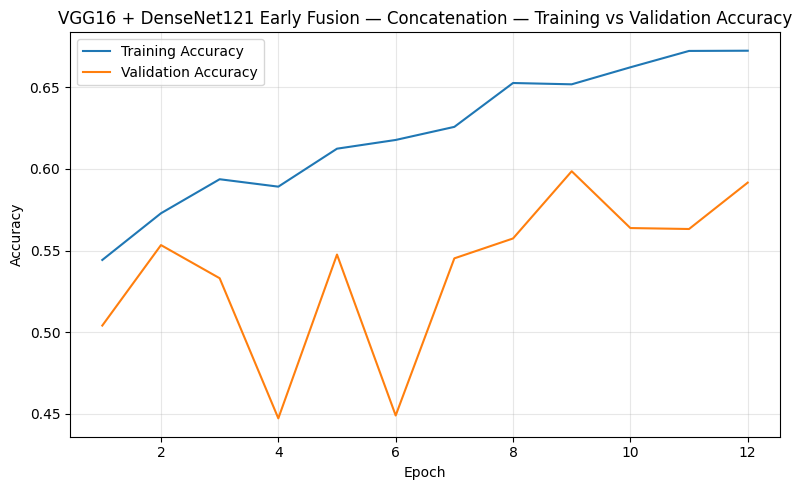

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_accuracy.png


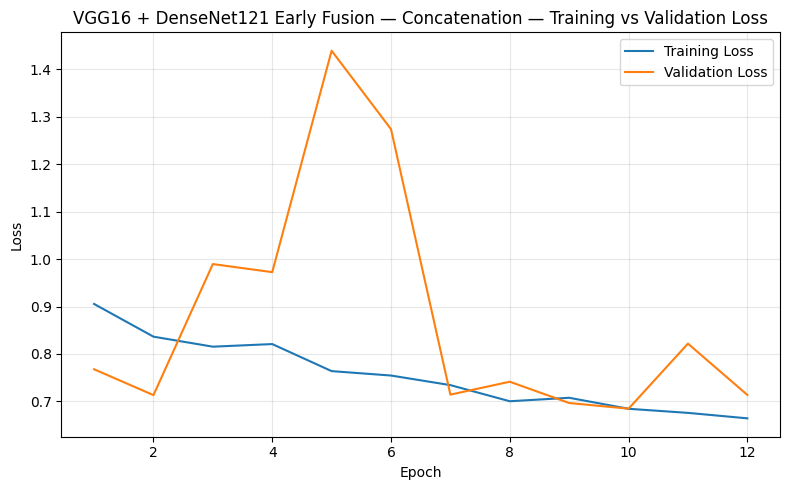

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_loss.png


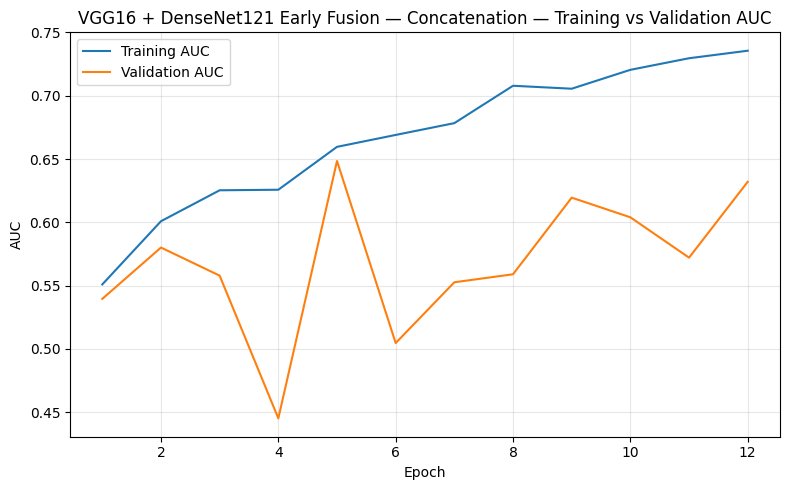

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step

VGG16 + DenseNet121 Early Fusion — Concatenation
PATIENT-LEVEL METRICS
{
  "accuracy": 0.75,
  "precision": 0.6666666666666666,
  "recall": 1.0,
  "specificity": 0.5,
  "negative_predictive_value": 1.0,
  "f1_score": 0.8,
  "balanced_accuracy": 0.75,
  "matthews_correlation_coefficient": 0.5773502691896258,
  "roc_auc": 0.875,
  "true_negative": 2,
  "false_positive": 2,
  "false_negative": 0,
  "true_positive": 4,
  "threshold": 0.5
}

Patient-Level Classification Report:
              precision    recall  f1-score   support

     Healthy     1.0000    0.5000    0.6667         4
   Parkinson     0.6667    1.0000    0.8000         4

    accuracy                         0.7500         8
   macro avg     0.8333    0.7500    0.7333         8
weighted avg     0.8333    0.7500    0.733

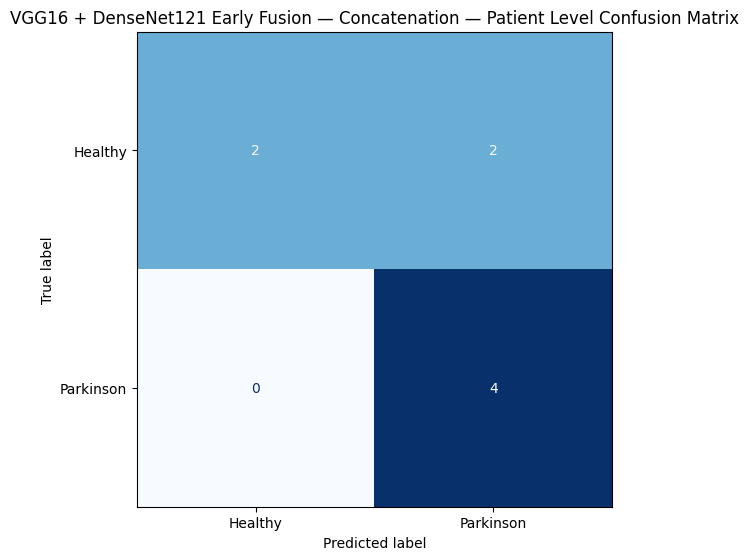

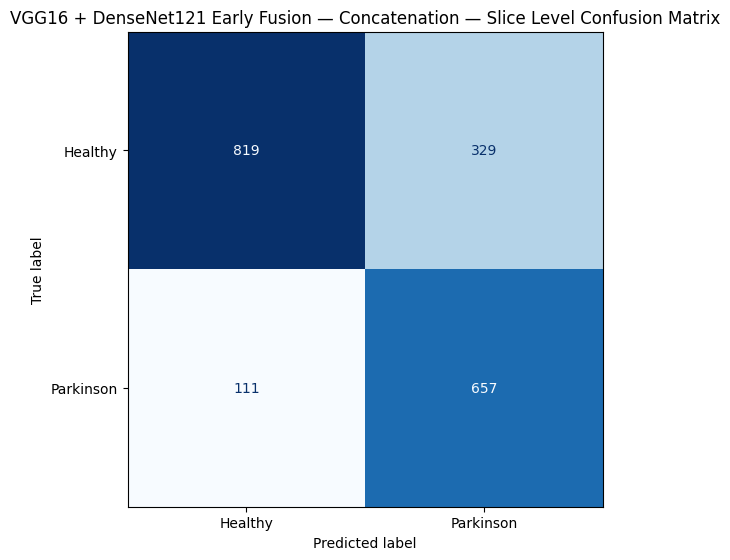

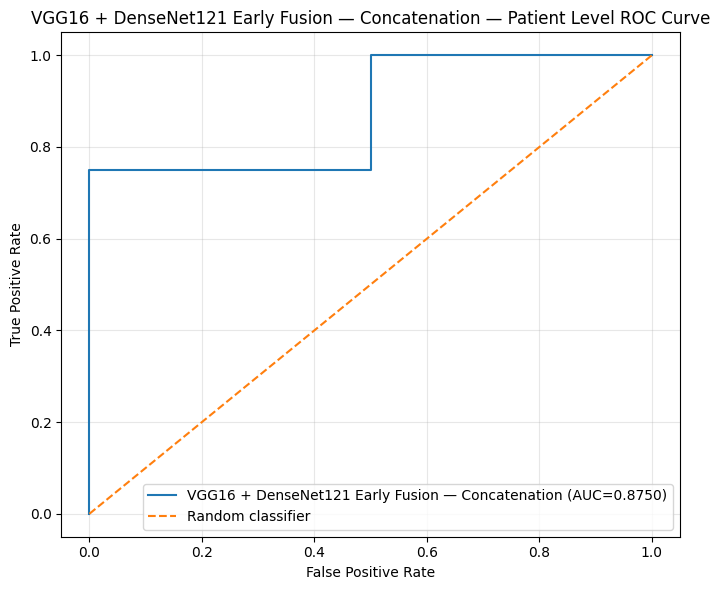

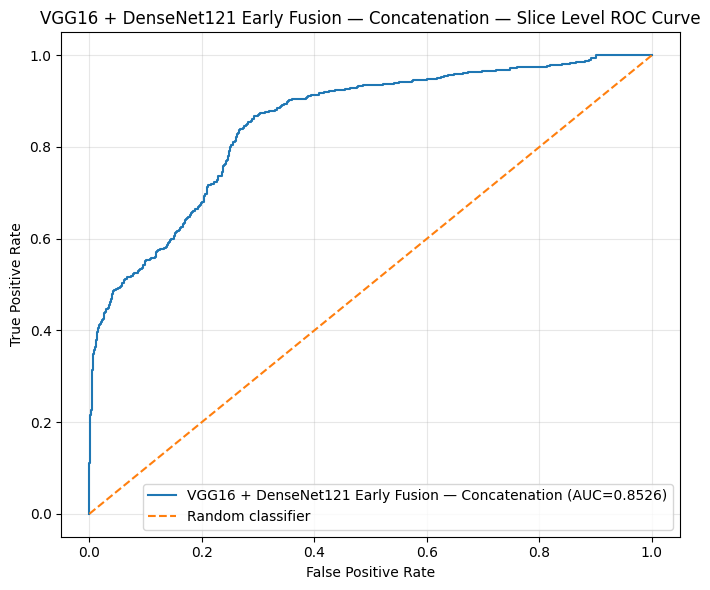

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_model_summary.txt
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_parameters.csv
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_patient_level_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_slice_level_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artif

In [13]:
# ================================
# TRAIN MODEL A: CONCATENATION FUSION
# ================================

model_name_concat = (
    "VGG16 + DenseNet121 Early Fusion "
    "— Concatenation"
)

concat_prefix = (
    "vgg16_densenet_concat_early_fusion"
)

concat_checkpoint_path = os.path.join(
    MODEL_DIR,
    (
        "VGG16_DenseNet121_Early_Fusion_"
        "Concatenation_best.keras"
    ),
)

concat_model = (
    build_vgg16_densenet_concat_model(
        base_trainable=True
    )
)

concat_model.summary()

# Same callbacks and settings as the uploaded notebook.
callbacks_concat = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=concat_checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    CSVLogger(
        filename=os.path.join(
            HISTORY_DIR,
            (
                f"{concat_prefix}_"
                "training_log.csv"
            ),
        )
    ),
]

history_concat = concat_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_concat,
)

concat_final_path = os.path.join(
    MODEL_DIR,
    (
        "VGG16_DenseNet121_Early_Fusion_"
        "Concatenation_final.keras"
    ),
)

concat_model.save(
    concat_final_path
)

print(
    "Final model saved:",
    concat_final_path,
)

history_concat_path = os.path.join(
    HISTORY_DIR,
    f"{concat_prefix}_history.json",
)

with open(
    history_concat_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history_concat.history,
        file,
    )

print(
    "History saved:",
    history_concat_path,
)

plot_training_history(
    history_concat,
    model_name_concat,
    concat_prefix,
)

# Free the final-epoch model before loading the saved best checkpoint.
del concat_model
gc.collect()
tf.keras.backend.clear_session()

concat_best_model = (
    load_saved_fusion_model(
        concat_checkpoint_path
    )
)

results_concat = evaluate_model(
    concat_best_model,
    test_gen,
    model_name_concat,
    concat_prefix,
)

results_concat[
    "checkpoint_path"
] = concat_checkpoint_path

results_concat[
    "final_model_path"
] = concat_final_path

del concat_best_model
del history_concat
gc.collect()
tf.keras.backend.clear_session()

print(
    "Concatenation model released "
    "from memory."
)

Model: "VGG16_DenseNet121_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocessin… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preproces… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (DenseNetPreproces… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121_backbo… │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_gap        │ (None, 1024)      │          0 │ densenet121_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_projected  │ (None, 256)       │    262,400 │ densenet_gap[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ vgg16_projected[… │
│ (Concatenate)       │                   │            │ densenet_project… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_densenet_… │ (None, 256)       │          0 │ densenet_project… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_vgg16_f… │
│ (Add)               │                   │            │ weighted_densene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ early_fusion_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,247,299 (84.87 MB)

 Trainable params: 22,162,883 (84.54 MB)

 Non-trainable params: 84,416 (329.75 KB)

Epoch 1/35
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5709 - auc: 0.5948 - loss: 0.8490
Epoch 1: val_auc improved from None to 0.52929, saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 327s 136ms/step - accuracy: 0.6068 - auc: 0.6483 - loss: 0.7883 - val_accuracy: 0.5568 - val_auc: 0.5293 - val_loss: 0.8375 - learning_rate: 1.0000e-05
Epoch 2/35
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6731 - auc: 0.7472 - loss: 0.6646
Epoch 2: val_auc improved from 0.52929 to 0.59416, saving model to /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/models/VGG16_DenseNet121_Early_Fusion_Attention_best

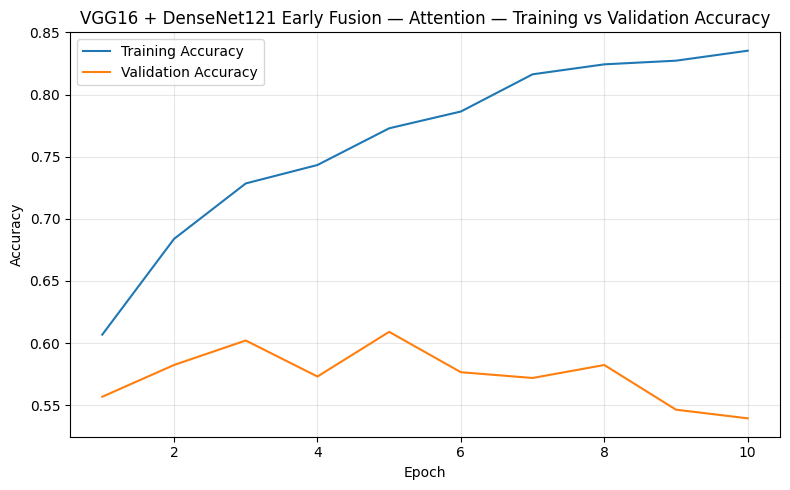

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_accuracy.png


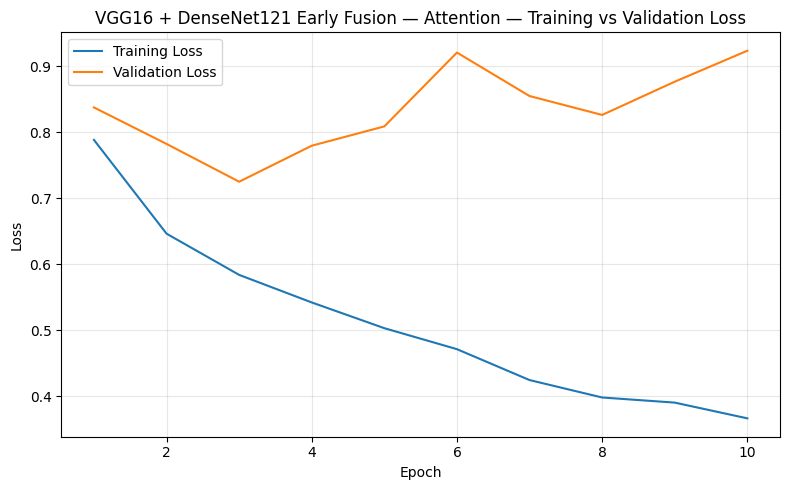

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_loss.png


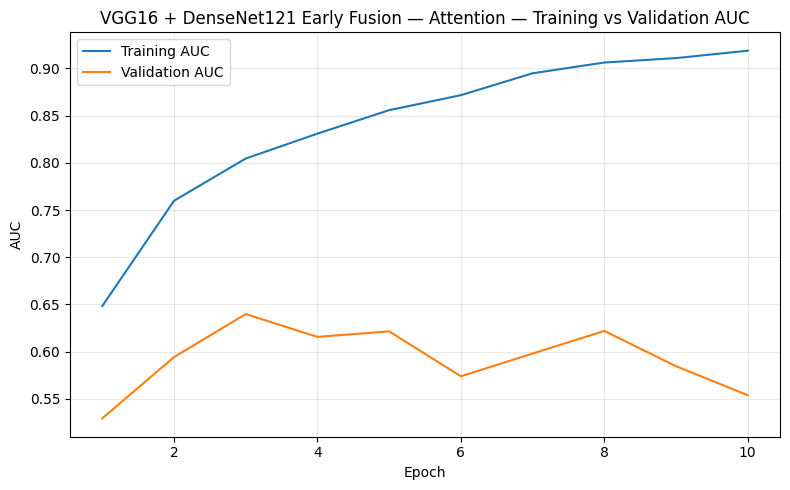

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step

VGG16 + DenseNet121 Early Fusion — Attention
PATIENT-LEVEL METRICS
{
  "accuracy": 0.75,
  "precision": 0.75,
  "recall": 0.75,
  "specificity": 0.75,
  "negative_predictive_value": 0.75,
  "f1_score": 0.75,
  "balanced_accuracy": 0.75,
  "matthews_correlation_coefficient": 0.5,
  "roc_auc": 0.875,
  "true_negative": 3,
  "false_positive": 1,
  "false_negative": 1,
  "true_positive": 3,
  "threshold": 0.5
}

Patient-Level Classification Report:
              precision    recall  f1-score   support

     Healthy     0.7500    0.7500    0.7500         4
   Parkinson     0.7500    0.7500    0.7500         4

    accuracy                         0.7500         8
   macro avg     0.7500    0.7500    0.7500         8
weighted avg     0.7500    0.7500    0.7500         8


SLICE-LEVEL

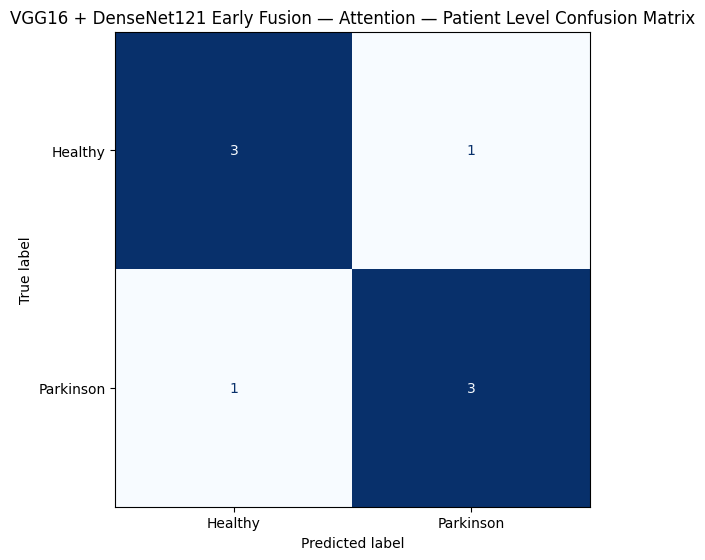

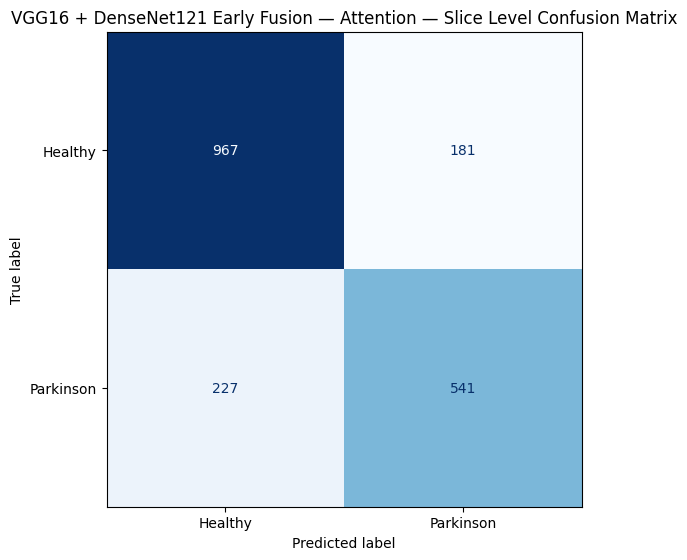

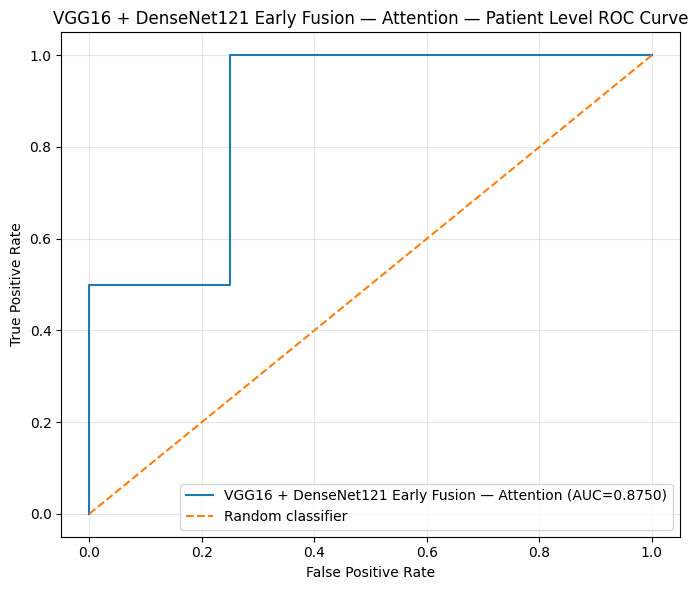

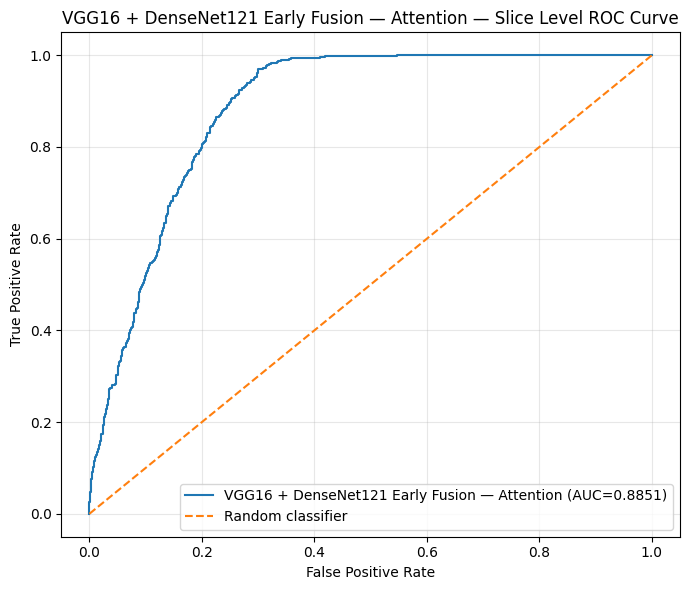

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_model_summary.txt
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_parameters.csv
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_patient_level_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_slice_level_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_roc_data.npz
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Pa

In [14]:
# ================================
# TRAIN MODEL B: ATTENTION FUSION
# ================================

model_name_attention = (
    "VGG16 + DenseNet121 Early Fusion "
    "— Attention"
)

attention_prefix = (
    "vgg16_densenet_attention_early_fusion"
)

attention_checkpoint_path = os.path.join(
    MODEL_DIR,
    (
        "VGG16_DenseNet121_Early_Fusion_"
        "Attention_best.keras"
    ),
)

attention_model = (
    build_vgg16_densenet_attention_model(
        base_trainable=True
    )
)

attention_model.summary()

# Same callbacks and settings as the uploaded notebook.
callbacks_attention = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=attention_checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    CSVLogger(
        filename=os.path.join(
            HISTORY_DIR,
            (
                f"{attention_prefix}_"
                "training_log.csv"
            ),
        )
    ),
]

history_attention = attention_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_attention,
)

attention_final_path = os.path.join(
    MODEL_DIR,
    (
        "VGG16_DenseNet121_Early_Fusion_"
        "Attention_final.keras"
    ),
)

attention_model.save(
    attention_final_path
)

print(
    "Final model saved:",
    attention_final_path,
)

history_attention_path = os.path.join(
    HISTORY_DIR,
    f"{attention_prefix}_history.json",
)

with open(
    history_attention_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history_attention.history,
        file,
    )

print(
    "History saved:",
    history_attention_path,
)

plot_training_history(
    history_attention,
    model_name_attention,
    attention_prefix,
)

del attention_model
gc.collect()
tf.keras.backend.clear_session()

attention_best_model = (
    load_saved_fusion_model(
        attention_checkpoint_path
    )
)

results_attention = evaluate_model(
    attention_best_model,
    test_gen,
    model_name_attention,
    attention_prefix,
)

results_attention[
    "checkpoint_path"
] = attention_checkpoint_path

results_attention[
    "final_model_path"
] = attention_final_path

del attention_best_model
del history_attention
gc.collect()
tf.keras.backend.clear_session()

print(
    "Attention model released "
    "from memory."
)

In [15]:
# ================================
# PATIENT-LEVEL MODEL COMPARISON
# ================================

fusion_comparison_df = pd.DataFrame(
    [
        {
            "Model": (
                results_concat[
                    "model_name"
                ]
            ),
            "Fusion Method": (
                "Concatenation"
            ),
            "Backbones": (
                "VGG16 + DenseNet121"
            ),
            "Evaluation Level": (
                "Patient"
            ),
            "Accuracy": (
                results_concat[
                    "accuracy"
                ]
            ),
            "Precision": (
                results_concat[
                    "precision"
                ]
            ),
            "Recall": (
                results_concat[
                    "recall"
                ]
            ),
            "Specificity": (
                results_concat[
                    "specificity"
                ]
            ),
            "F1 Score": (
                results_concat[
                    "f1_score"
                ]
            ),
            "Balanced Accuracy": (
                results_concat[
                    "balanced_accuracy"
                ]
            ),
            "MCC": results_concat["mcc"],
            "ROC AUC": (
                results_concat[
                    "roc_auc"
                ]
            ),
            "Test Patients": len(
                results_concat[
                    "y_true"
                ]
            ),
            "Total Parameters": (
                results_concat[
                    "total_params"
                ]
            ),
            "Trainable Parameters": (
                results_concat[
                    "trainable_params"
                ]
            ),
            "Non-Trainable Parameters": (
                results_concat[
                    "non_trainable_params"
                ]
            ),
            "Split Fingerprint": (
                split_fingerprint
            ),
        },
        {
            "Model": (
                results_attention[
                    "model_name"
                ]
            ),
            "Fusion Method": (
                "Attention"
            ),
            "Backbones": (
                "VGG16 + DenseNet121"
            ),
            "Evaluation Level": (
                "Patient"
            ),
            "Accuracy": (
                results_attention[
                    "accuracy"
                ]
            ),
            "Precision": (
                results_attention[
                    "precision"
                ]
            ),
            "Recall": (
                results_attention[
                    "recall"
                ]
            ),
            "Specificity": (
                results_attention[
                    "specificity"
                ]
            ),
            "F1 Score": (
                results_attention[
                    "f1_score"
                ]
            ),
            "Balanced Accuracy": (
                results_attention[
                    "balanced_accuracy"
                ]
            ),
            "MCC": (
                results_attention[
                    "mcc"
                ]
            ),
            "ROC AUC": (
                results_attention[
                    "roc_auc"
                ]
            ),
            "Test Patients": len(
                results_attention[
                    "y_true"
                ]
            ),
            "Total Parameters": (
                results_attention[
                    "total_params"
                ]
            ),
            "Trainable Parameters": (
                results_attention[
                    "trainable_params"
                ]
            ),
            "Non-Trainable Parameters": (
                results_attention[
                    "non_trainable_params"
                ]
            ),
            "Split Fingerprint": (
                split_fingerprint
            ),
        },
    ]
)

comparison_path = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "comparison.csv"
    ),
)

fusion_comparison_df.to_csv(
    comparison_path,
    index=False,
)

print(
    "Comparison saved:",
    comparison_path,
)

print(
    fusion_comparison_df.to_string(
        index=False
    )
)


all_results = [
    results_concat,
    results_attention,
]

best_result = max(
    all_results,
    key=lambda result: (
        result["roc_auc"],
        result["f1_score"],
        result["accuracy"],
    ),
)

BEST_FUSION_MODEL_NAME = (
    best_result["model_name"]
)

BEST_FUSION_MODEL_PATH = (
    best_result["checkpoint_path"]
)

BEST_FUSION_PREFIX = (
    best_result["file_prefix"]
)

print(
    "\nBest patient-level "
    "early-fusion model:",
    BEST_FUSION_MODEL_NAME,
)

print(
    "Best model path:",
    BEST_FUSION_MODEL_PATH,
)


best_fpr, best_tpr, best_thresholds = (
    roc_curve(
        best_result["y_true"],
        best_result["y_prob"],
    )
)

best_roc_alias = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "roc_data.npz"
    ),
)

np.savez_compressed(
    best_roc_alias,
    patient_ids=np.asarray(
        best_result["patient_ids"],
        dtype="U",
    ),
    y_true=np.asarray(
        best_result["y_true"],
        dtype=np.int32,
    ),
    y_prob=np.asarray(
        best_result["y_prob"],
        dtype=np.float64,
    ),
    y_pred=np.asarray(
        best_result["y_pred"],
        dtype=np.int32,
    ),
    fpr=best_fpr,
    tpr=best_tpr,
    thresholds=best_thresholds,
    auc=np.asarray(
        best_result["roc_auc"],
        dtype=np.float64,
    ),
    model_name=np.asarray(
        BEST_FUSION_MODEL_NAME
    ),
    evaluation_level=np.asarray(
        "patient_level"
    ),
    split_fingerprint=np.asarray(
        split_fingerprint
    ),
)

print(
    "Best-model patient ROC alias saved:",
    best_roc_alias,
)


best_summary_path = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "best_model_summary.txt"
    ),
)

with open(
    best_summary_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(
        f"Best model: "
        f"{BEST_FUSION_MODEL_NAME}\n"
    )
    file.write(
        f"Checkpoint: "
        f"{BEST_FUSION_MODEL_PATH}\n"
    )
    file.write(
        "Evaluation level: Patient\n"
    )
    file.write(
        f"Split fingerprint: "
        f"{split_fingerprint}\n"
    )
    file.write(
        f"Accuracy: "
        f"{best_result['accuracy']:.8f}\n"
    )
    file.write(
        f"Precision: "
        f"{best_result['precision']:.8f}\n"
    )
    file.write(
        f"Recall: "
        f"{best_result['recall']:.8f}\n"
    )
    file.write(
        f"Specificity: "
        f"{best_result['specificity']:.8f}\n"
    )
    file.write(
        f"F1 Score: "
        f"{best_result['f1_score']:.8f}\n"
    )
    file.write(
        f"Balanced Accuracy: "
        f"{best_result['balanced_accuracy']:.8f}\n"
    )
    file.write(
        f"MCC: "
        f"{best_result['mcc']:.8f}\n"
    )
    file.write(
        f"ROC AUC: "
        f"{best_result['roc_auc']:.8f}\n"
    )
    file.write(
        f"Total Parameters: "
        f"{best_result['total_params']}\n"
    )
    file.write(
        f"Trainable Parameters: "
        f"{best_result['trainable_params']}\n"
    )
    file.write(
        f"Non-Trainable Parameters: "
        f"{best_result['non_trainable_params']}\n"
    )

print("Saved:", best_summary_path)


best_parameters_alias = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "best_model_parameters.csv"
    ),
)

shutil.copyfile(
    best_result["parameter_path"],
    best_parameters_alias,
)

print(
    "Saved:",
    best_parameters_alias,
)

Comparison saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_comparison.csv
                                           Model Fusion Method           Backbones Evaluation Level  Accuracy  Precision  Recall  Specificity  F1 Score  Balanced Accuracy     MCC  ROC AUC  Test Patients  Total Parameters  Trainable Parameters  Non-Trainable Parameters Split Fingerprint
VGG16 + DenseNet121 Early Fusion — Concatenation Concatenation VGG16 + DenseNet121          Patient      0.75   0.666667    1.00         0.50      0.80               0.75 0.57735    0.875              8          22707073              22621633                     85440  5139acdd63ebe379
    VGG16 + DenseNet121 Early Fusion — Attention     Attention VGG16 + DenseNet121          Patient      0.75   0.750000    0.75         0.75      0.75               0.75 0.50000    0.875              8          22247299              22162883        

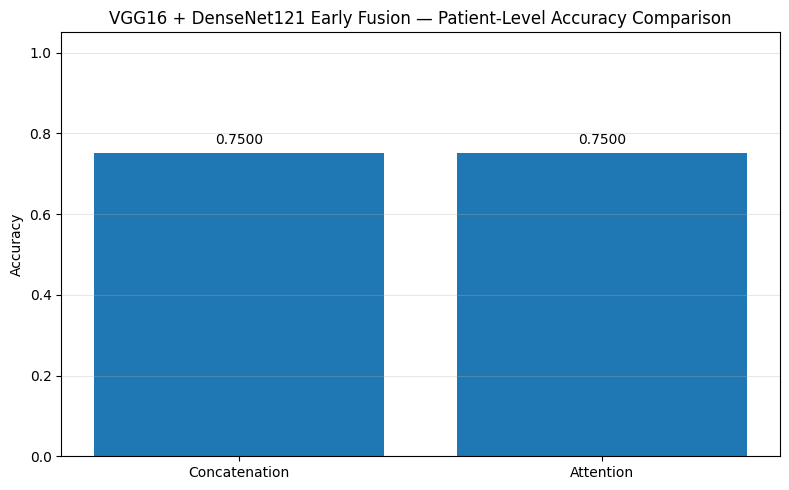

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_accuracy_comparison.png


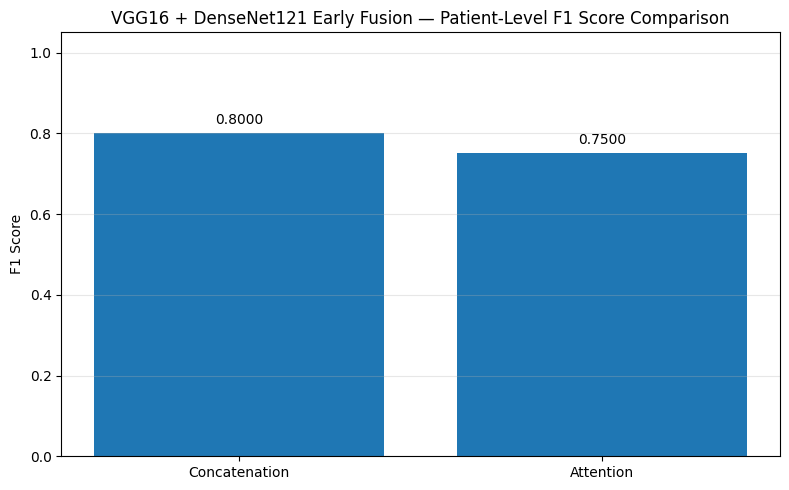

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_f1_comparison.png


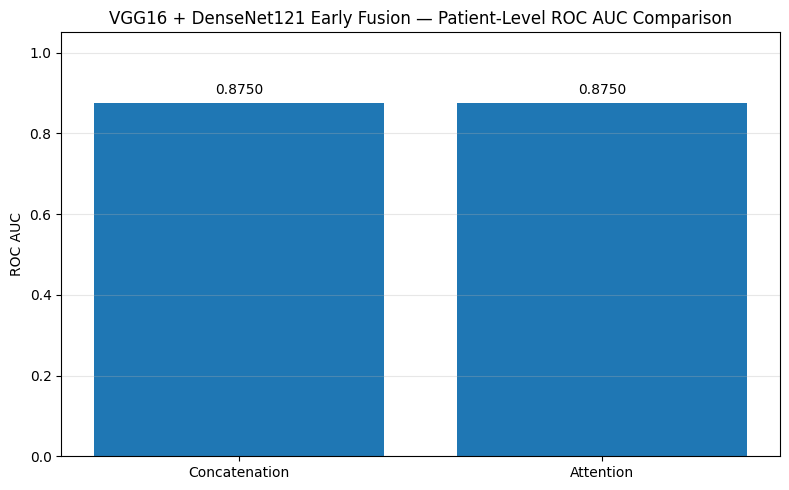

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_auc_comparison.png


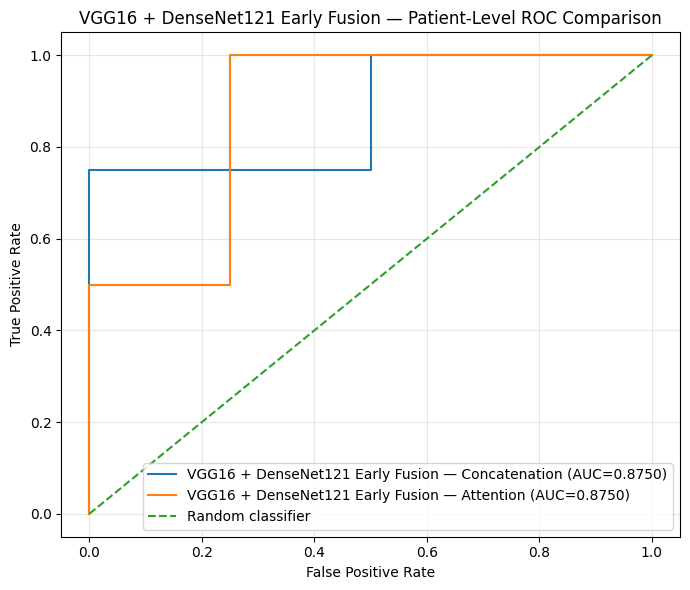

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_combined_roc_curve.png
Combined ROC NPZ keys: ['patient_ids', 'y_true', 'split_fingerprint', 'concatenation_y_prob', 'concatenation_y_pred', 'concatenation_fpr', 'concatenation_tpr', 'concatenation_thresholds', 'concatenation_auc', 'attention_y_prob', 'attention_y_pred', 'attention_fpr', 'attention_tpr', 'attention_thresholds', 'attention_auc']
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_combined_patient_roc_data.npz


In [16]:
# ================================
# SAME COMPARISON GRAPHS + PATIENT-LEVEL COMBINED ROC
# ================================

for metric, ylabel, filename in [
    (
        "Accuracy",
        "Accuracy",
        (
            "vgg16_densenet_early_fusion_"
            "accuracy_comparison.png"
        ),
    ),
    (
        "F1 Score",
        "F1 Score",
        (
            "vgg16_densenet_early_fusion_"
            "f1_comparison.png"
        ),
    ),
    (
        "ROC AUC",
        "ROC AUC",
        (
            "vgg16_densenet_early_fusion_"
            "auc_comparison.png"
        ),
    ),
]:
    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        fusion_comparison_df[
            "Fusion Method"
        ],
        fusion_comparison_df[
            metric
        ],
    )

    plt.title(
        "VGG16 + DenseNet121 "
        "Early Fusion — Patient-Level "
        f"{ylabel} Comparison"
    )

    plt.ylabel(ylabel)
    plt.ylim(0, 1.05)
    plt.grid(
        axis="y",
        alpha=0.3,
    )

    for bar in bars:
        value = bar.get_height()

        plt.text(
            (
                bar.get_x()
                + bar.get_width() / 2
            ),
            min(
                value + 0.015,
                1.03,
            ),
            f"{value:.4f}",
            ha="center",
            va="bottom",
        )

    save_path = os.path.join(
        ROOT_OUTPUT_DIR,
        filename,
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", save_path)


figure, axis = plt.subplots(
    figsize=(7, 6)
)

combined_npz_data = {
    "patient_ids": np.asarray(
        results_concat[
            "patient_ids"
        ],
        dtype="U",
    ),
    "y_true": np.asarray(
        results_concat["y_true"],
        dtype=np.int32,
    ),
    "split_fingerprint": (
        np.asarray(
            split_fingerprint
        )
    ),
}

for result, short_name in [
    (
        results_concat,
        "concatenation",
    ),
    (
        results_attention,
        "attention",
    ),
]:
    if not np.array_equal(
        results_concat[
            "patient_ids"
        ],
        result["patient_ids"],
    ):
        raise ValueError(
            "Patient order differs between "
            "the two model results."
        )

    if not np.array_equal(
        results_concat["y_true"],
        result["y_true"],
    ):
        raise ValueError(
            "Patient labels differ between "
            "the two model results."
        )

    fpr, tpr, thresholds = roc_curve(
        result["y_true"],
        result["y_prob"],
    )

    axis.plot(
        fpr,
        tpr,
        label=(
            f"{result['model_name']} "
            f"(AUC="
            f"{result['roc_auc']:.4f})"
        ),
    )

    combined_npz_data[
        f"{short_name}_y_prob"
    ] = np.asarray(
        result["y_prob"],
        dtype=np.float64,
    )

    combined_npz_data[
        f"{short_name}_y_pred"
    ] = np.asarray(
        result["y_pred"],
        dtype=np.int32,
    )

    combined_npz_data[
        f"{short_name}_fpr"
    ] = np.asarray(
        fpr,
        dtype=np.float64,
    )

    combined_npz_data[
        f"{short_name}_tpr"
    ] = np.asarray(
        tpr,
        dtype=np.float64,
    )

    combined_npz_data[
        f"{short_name}_thresholds"
    ] = np.asarray(
        thresholds,
        dtype=np.float64,
    )

    combined_npz_data[
        f"{short_name}_auc"
    ] = np.asarray(
        result["roc_auc"],
        dtype=np.float64,
    )


axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

axis.set_xlabel(
    "False Positive Rate"
)
axis.set_ylabel(
    "True Positive Rate"
)
axis.set_title(
    "VGG16 + DenseNet121 "
    "Early Fusion — Patient-Level "
    "ROC Comparison"
)
axis.legend(
    loc="lower right"
)
axis.grid(alpha=0.3)

figure.tight_layout()

combined_roc_path = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "combined_roc_curve.png"
    ),
)

figure.savefig(
    combined_roc_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print("Saved:", combined_roc_path)


combined_roc_npz_path = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "combined_patient_roc_data.npz"
    ),
)

np.savez_compressed(
    combined_roc_npz_path,
    **combined_npz_data,
)

with np.load(
    combined_roc_npz_path,
    allow_pickle=False,
) as verification:
    print(
        "Combined ROC NPZ keys:",
        verification.files,
    )

print(
    "Saved:",
    combined_roc_npz_path,
)

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt

# ================================
# KERAS 3–SAFE BRANCH-WISE GRAD-CAM FOR THE BEST FUSION MODEL
# ================================

GRADCAM_FILE_PREFIX = "vgg16_densenet_early_fusion"

def load_fusion_model_safely(model_path):
    # Define custom objects needed for loading models, including new custom preprocessing layers.
    custom_objects = {
        "VGG16PreprocessingLayer": VGG16PreprocessingLayer,
        "DenseNetPreprocessingLayer": DenseNetPreprocessingLayer,
        # Include any other custom objects if needed (e.g., specific Lambda functions if not replaced)
    }
    try:
        return keras.models.load_model(
            model_path,
            compile=False,
            safe_mode=False,
            custom_objects=custom_objects,  # Pass custom objects here
        )
    except TypeError:
        # Compatibility fallback for TensorFlow versions without safe_mode.
        return keras.models.load_model(
            model_path,
            compile=False,
            custom_objects=custom_objects,  # Pass custom objects here as well
        )


def call_layer_inference(layer, inputs):
    try:
        return layer(inputs, training=False)
    except TypeError:
        return layer(inputs)


def resolve_conv_layer(backbone, candidates):
    for layer_name in candidates:
        try:
            layer = backbone.get_layer(layer_name)
            if len(layer.output.shape) == 4:
                return layer
        except (ValueError, AttributeError):
            continue

    conv_layers = [
        layer
        for layer in backbone.layers
        if isinstance(layer, layers.Conv2D) and len(layer.output.shape) == 4
    ]

    if not conv_layers:
        raise ValueError(
            f"No valid Conv2D layer was found inside {backbone.name}."
        )

    return conv_layers[-1]


def build_early_fusion_gradcam_context(model):
    if len(model.inputs) != 1:
        raise ValueError(
            f"This notebook model is expected to have one shared MRI input, "
            f"but {len(model.inputs)} inputs were found."
        )

    vgg_backbone = model.get_layer("vgg16_backbone")
    dense_backbone = model.get_layer("densenet121_backbone")

    vgg_conv_layer = resolve_conv_layer(
        vgg_backbone,
        ["block5_conv3", "block5_conv2", "block5_conv1"],
    )
    dense_conv_layer = resolve_conv_layer(
        dense_backbone,
        [
            "conv5_block16_2_conv",
            "conv5_block16_1_conv",
            "conv5_block15_2_conv",
        ],
    )

    # Each probe uses the nested backbone's own graph, avoiding Keras 3
    # disconnected-graph and Functional.call KeyErrors.
    vgg_probe = keras.Model(
        inputs=vgg_backbone.input,
        outputs=[vgg_conv_layer.output, vgg_backbone.output],
        name="vgg16_gradcam_probe",
    )
    dense_probe = keras.Model(
        inputs=dense_backbone.input,
        outputs=[dense_conv_layer.output, dense_backbone.output],
        name="densenet121_gradcam_probe",
    )

    if "early_fusion_concatenation" in [layer.name for layer in model.layers]:
        fusion_type = "Concatenation"
        fusion_layer = model.get_layer("early_fusion_concatenation")
    elif "early_fusion_attention" in [layer.name for layer in model.layers]:
        fusion_type = "Attention"
        fusion_layer = model.get_layer("early_fusion_attention")
    else:
        raise ValueError("A supported early-fusion layer was not found.")

    prediction_layer = model.get_layer("prediction")

    context = {
        "model": model,
        "vgg_backbone": vgg_backbone,
        "dense_backbone": dense_backbone,
        "vgg_conv_layer": vgg_conv_layer,
        "dense_conv_layer": dense_conv_layer,
        "vgg_probe": vgg_probe,
        "dense_probe": dense_probe,
        "fusion_type": fusion_type,
        "fusion_layer": fusion_layer,
        "prediction_layer": prediction_layer,
    }

    print("Loaded best model:", model.name)
    print("Fusion type:", fusion_type)
    print("Model input shape:", model.input_shape)
    print("VGG16 Grad-CAM layer:", vgg_conv_layer.name, vgg_conv_layer.output.shape)
    print(
        "DenseNet121 Grad-CAM layer:",
        dense_conv_layer.name, dense_conv_layer.output.shape,
    )

    return context


def forward_with_branch_feature_maps(context, image_batch):
    model = context["model"]

    vgg_input = call_layer_inference(
        model.get_layer("vgg16_preprocessing"),
        image_batch,
    )
    dense_input = call_layer_inference(
        model.get_layer("densenet_preprocessing"),
        image_batch,
    )

    vgg_conv, vgg_output = context["vgg_probe"](
        vgg_input,
        training=False,
    )
    dense_conv, dense_output = context["dense_probe"](
        dense_input,
        training=False,
    )

    vgg_vector = call_layer_inference(
        model.get_layer("vgg16_gap"),
        vgg_output,
    )
    dense_vector = call_layer_inference(
        model.get_layer("densenet_gap"),
        dense_output,
    )

    if context["fusion_type"] == "Concatenation":
        fused = call_layer_inference(
            context["fusion_layer"],
            [vgg_vector, dense_vector],
        )
    else:
        vgg_projected = call_layer_inference(
            model.get_layer("vgg16_projected"),
            vgg_vector,
        )
        dense_projected = call_layer_inference(
            model.get_layer("densenet_projected"),
            dense_vector,
        )
        attention_input = call_layer_inference(
            model.get_layer("attention_input"),
            [vgg_projected, dense_projected],
        )
        attention_weights = call_layer_inference(
            model.get_layer("branch_attention_weights"),
            attention_input,
        )
        weighted_vgg = call_layer_inference(
            model.get_layer("weighted_vgg16_features"),
            [vgg_projected, attention_weights],
        )
        weighted_dense = call_layer_inference(
            model.get_layer("weighted_densenet_features"),
            [dense_projected, attention_weights],
        )
        fused = call_layer_inference(
            context["fusion_layer"],
            [weighted_vgg, weighted_dense],
        )

    # Reuse every trained classifier-head layer after the fusion layer.
    fusion_index = model.layers.index(context["fusion_layer"])
    x = fused

    for layer in model.layers[fusion_index + 1 :]:
        if layer.name == "prediction":
            break
        x = call_layer_inference(layer, x)

    # Calculate the true pre-sigmoid logit from the trained final layer.
    prediction_layer = context["prediction_layer"]
    logits = tf.linalg.matmul(x, prediction_layer.kernel)
    if prediction_layer.use_bias:
        logits = tf.nn.bias_add(logits, prediction_layer.bias)
    probabilities = tf.nn.sigmoid(logits)

    return vgg_conv, dense_conv, logits, probabilities


def heatmap_from_gradient(feature_maps, gradients):
    # Determine the shape for a zero heatmap
    initial_heatmap_shape = feature_maps.shape[1:3]
    zero_heatmap_array = tf.zeros(initial_heatmap_shape, dtype=tf.float32).numpy().astype(np.float32)

    diagnostics = {
        "valid": True,
        "reason": "",
        "gradient_norm": 0.0,
        "raw_max": 0.0,
        "heatmap_max": 0.0,
        "nonzero_fraction": 0.0,
    }

    if gradients is None:
        diagnostics.update({
            "valid": False,
            "reason": "Gradients are None",
        })
        return zero_heatmap_array, diagnostics

    gradient_norm = float(tf.norm(gradients).numpy())
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    raw_heatmap = tf.reduce_sum(
        feature_maps[0] * pooled_gradients,
        axis=-1,
    )
    raw_heatmap = tf.nn.relu(raw_heatmap)
    raw_max = float(tf.reduce_max(raw_heatmap).numpy())

    diagnostics.update({
        "gradient_norm": gradient_norm,
        "raw_max": raw_max,
    })

    if not np.isfinite(gradient_norm) or not np.isfinite(raw_max):
        diagnostics.update({
            "valid": False,
            "reason": "Non-finite gradient or heatmap",
        })
        return zero_heatmap_array, diagnostics

    # If the gradient is zero, the heatmap should be zero.
    if gradient_norm <= 0.0:
        diagnostics.update({
            "valid": False,
            "reason": "Zero gradient",
        })
        return zero_heatmap_array, diagnostics

    # If raw_max is effectively zero, the heatmap will be all zeros after normalization.
    # We still compute it but mark it as invalid for interpretation.
    if raw_max <= 1e-12: # Use a very small epsilon to catch near-zero cases
        diagnostics.update({
            "valid": False,
            "reason": "Effectively zero positive activation (raw_max <= 1e-12)",
        })
        # To avoid division by zero if raw_max is literally 0.0, use a small epsilon for division
        effective_raw_max = max(raw_max, 1e-12)
        heatmap = (raw_heatmap / effective_raw_max).numpy().astype(np.float32)
    else:
        heatmap = (raw_heatmap / raw_max).numpy().astype(np.float32)

    nonzero_fraction = float(np.mean(heatmap > 1e-8))

    diagnostics.update({
        "heatmap_max": float(np.max(heatmap)),
        "nonzero_fraction": nonzero_fraction,
    })

    return heatmap, diagnostics


def make_vgg16_densenet_earlyfusion_gradcam(
    context,
    image_batch,
    target_class,
):
    image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

    if image_tensor.shape.rank == 3:
        image_tensor = tf.expand_dims(image_tensor, axis=0)

    with tf.GradientTape(persistent=True) as tape:
        vgg_maps, dense_maps, logits, probabilities = (
            forward_with_branch_feature_maps(context, image_tensor)
        )

        tape.watch(vgg_maps)
        tape.watch(dense_maps)

        logit = logits[0, 0]
        target_score = logit if int(target_class) == 1 else -logit

    vgg_gradients = tape.gradient(target_score, vgg_maps)
    dense_gradients = tape.gradient(target_score, dense_maps)
    del tape

    vgg_heatmap, vgg_diagnostics = heatmap_from_gradient(
        vgg_maps,
        vgg_gradients,
    )
    dense_heatmap, dense_diagnostics = heatmap_from_gradient(
        dense_maps,
        dense_gradients,
    )

    probability = float(probabilities[0, 0].numpy())
    predicted_class = int(probability >= 0.5)

    diagnostics = {
        "probability": probability,
        "predicted_class": predicted_class,
        "target_class": int(target_class),
        "target_logit": float(target_score.numpy()),
        "vgg": vgg_diagnostics,
        "dense": dense_diagnostics,
    }

    return vgg_heatmap, dense_heatmap, diagnostics


def resize_heatmap_and_overlay(original_rgb, heatmap, alpha=0.40):
    original = np.asarray(original_rgb, dtype=np.float32)
    if original.max() > 1.0:
        original = original / 255.0
    original = np.clip(original, 0.0, 1.0)

    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (original.shape[0], original.shape[1]),
        method="bilinear",
    ).numpy().squeeze()
    resized_heatmap = np.clip(resized_heatmap, 0.0, 1.0)

    # Matplotlib returns RGBA. Keep only RGB to prevent shape errors.
    colored_heatmap = plt.colormaps["jet"](resized_heatmap)[..., :3]
    overlay = np.clip(
        (1.0 - alpha) * original + alpha * colored_heatmap,
        0.0,
        1.0,
    )

    if original.shape[-1] != 3 or colored_heatmap.shape[-1] != 3:
        raise ValueError(
            f"RGB shape validation failed: image={original.shape}, "
            f"heatmap={colored_heatmap.shape}"
        )

    return resized_heatmap, overlay


def representative_image_score(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return -np.inf

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    foreground = image > 0.06
    foreground_ratio = float(foreground.mean())

    if foreground_ratio < 0.12 or foreground_ratio > 0.90:
        return -np.inf

    contrast = float(image[foreground].std()) if foreground.any() else 0.0
    central = foreground[
        int(0.08 * IMG_SIZE) : int(0.82 * IMG_SIZE),
        int(0.10 * IMG_SIZE) : int(0.90 * IMG_SIZE),
    ]
    central_ratio = float(central.mean())

    total_foreground = max(float(foreground.sum()), 1.0)
    bottom_fraction = float(
        foreground[int(0.78 * IMG_SIZE) :, :].sum() / total_foreground
    )

    if contrast < 0.04 or central_ratio < 0.10:
        return -np.inf

    return (
        2.0 * central_ratio
        + foreground_ratio
        + contrast
        - 1.5 * bottom_fraction
    )


def extract_patient_id(image_path):
    match = re.search(r"PPMI[_-](\d+)", os.path.basename(image_path), re.IGNORECASE)
    if match:
        return match.group(1)
    return os.path.basename(image_path).split("_slice")[0]


Loaded best model: VGG16_DenseNet121_Early_Fusion_Concatenation
Fusion type: Concatenation
Model input shape: (None, 224, 224, 3)
VGG16 Grad-CAM layer: block5_conv3 (None, 14, 14, 512)
DenseNet121 Grad-CAM layer: conv5_block16_2_conv (None, 7, 7, 32)


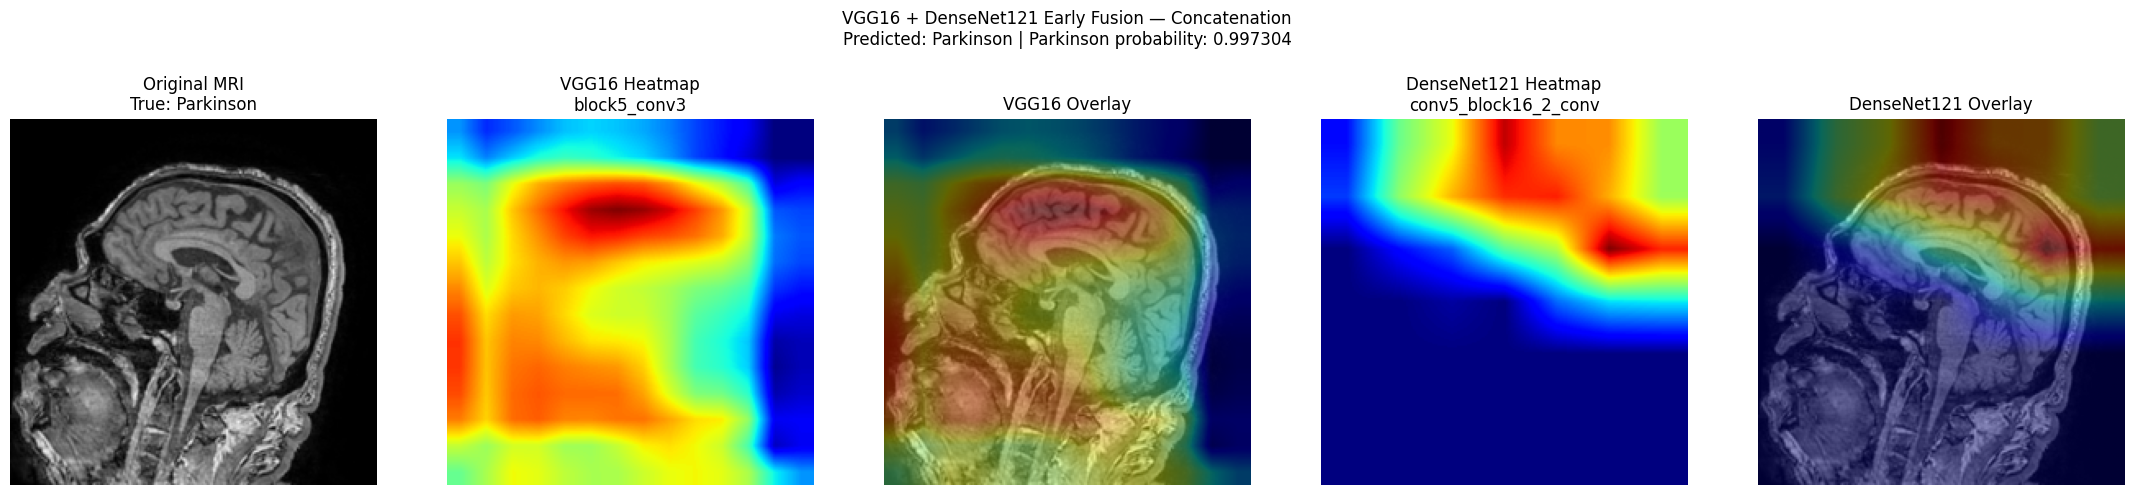

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_parkinson_1.png
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_parkinson_1.npz
VGG16 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 0.030137833207845688, 'raw_max': 0.19073568284511566, 'heatmap_max': 1.0, 'nonzero_fraction': 0.9795918367346939}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 0.2918536067008972, 'raw_max': 0.003924740012735128, 'heatmap_max': 1.0, 'nonzero_fraction': 0.4897959183673469}


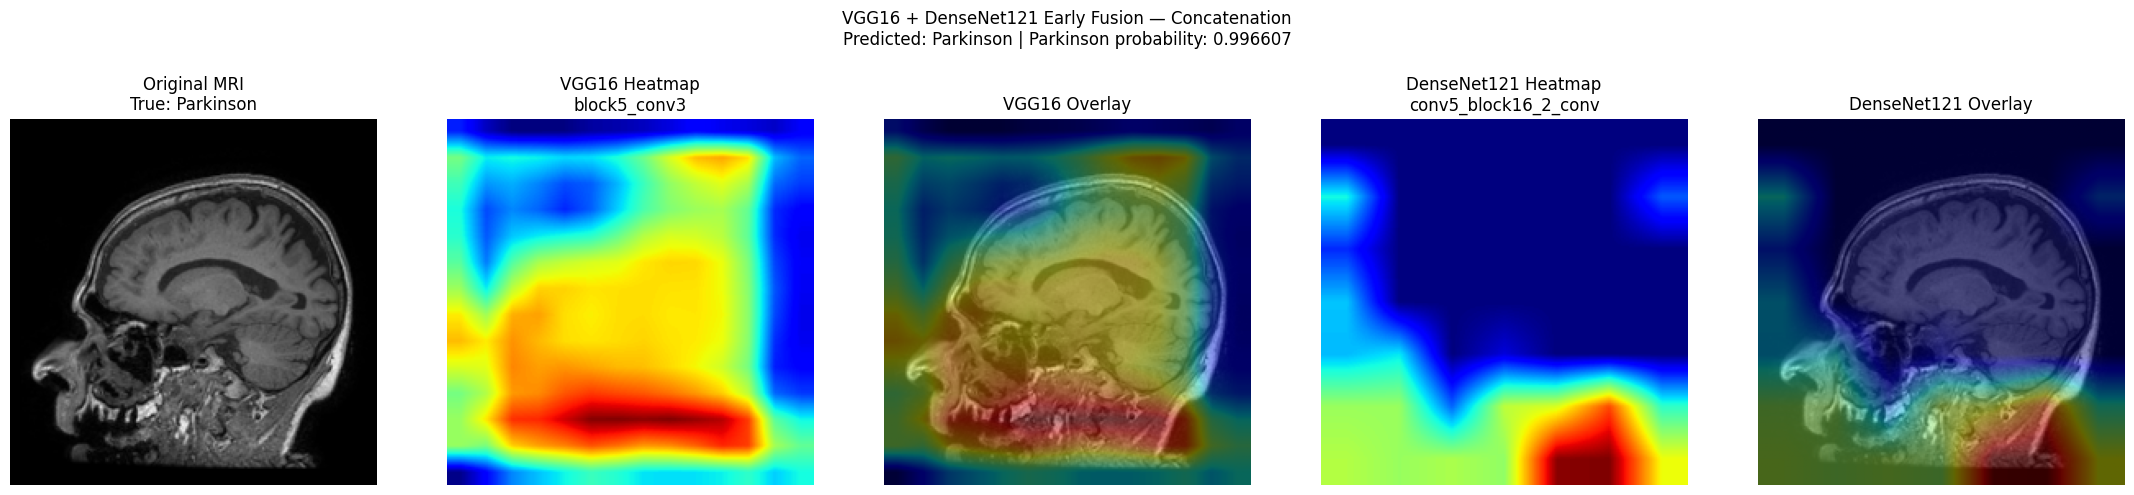

Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_parkinson_2.png
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_parkinson_2.npz
VGG16 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 0.1072438657283783, 'raw_max': 0.1678256094455719, 'heatmap_max': 1.0, 'nonzero_fraction': 0.9897959183673469}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 1.2456490993499756, 'raw_max': 0.005441395565867424, 'heatmap_max': 1.0, 'nonzero_fraction': 0.42857142857142855}
Saved: /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_results.csv
class_name  sample_number                                                                                                      

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt

# ================================
# GENERATE FOUR VALID BRANCH-WISE GRAD-CAM FIGURES
# ================================

best_fusion_model = load_fusion_model_safely(BEST_FUSION_MODEL_PATH)
gradcam_context = build_early_fusion_gradcam_context(best_fusion_model)

# Use the already evaluated best-model predictions, which are aligned with
# the non-shuffled test generator.
test_paths = list(getattr(test_gen, "filepaths", []))
test_labels = np.asarray(test_gen.classes).astype(np.int32)
best_probabilities = np.asarray(best_result["slice_y_prob"]).reshape(-1)

if not (
    len(test_paths) == len(test_labels) == len(best_probabilities)
):
    raise ValueError(
        "Grad-CAM input alignment failed: filepaths, labels, and probabilities "
        "do not have equal lengths."
    )

candidate_df = pd.DataFrame(
    {
        "image_path": test_paths,
        "true_label": test_labels,
        "probability": best_probabilities,
    }
)
candidate_df["predicted_label"] = (
    candidate_df["probability"] >= 0.5
).astype(np.int32)
candidate_df["correct"] = (
    candidate_df["true_label"] == candidate_df["predicted_label"]
)
candidate_df["patient_id"] = candidate_df["image_path"].map(extract_patient_id)
candidate_df["representative_score"] = candidate_df["image_path"].map(
    representative_image_score
)

selected_records = []
used_patient_ids = set()

for target_class, class_name in [(0, "Healthy"), (1, "Parkinson")]:
    class_candidates = candidate_df[
        (candidate_df["true_label"] == target_class)
        & (candidate_df["correct"])
        & np.isfinite(candidate_df["representative_score"])
    ].sort_values("representative_score", ascending=False)

    class_count = 0

    for _, row in class_candidates.head(100).iterrows():
        if row["patient_id"] in used_patient_ids:
            continue

        try:
            display_image = keras.utils.load_img(
                row["image_path"],
                target_size=(IMG_SIZE, IMG_SIZE),
                color_mode="rgb",
            )
            display_array = keras.utils.img_to_array(display_image).astype(np.float32)
            image_batch = np.expand_dims(display_array, axis=0)

            vgg_heatmap, dense_heatmap, diagnostics = (
                make_vgg16_densenet_earlyfusion_gradcam(
                    gradcam_context,
                    image_batch,
                    target_class=target_class,
                )
            )

            # Proceed if at least one heatmap is valid. Only skip if *both* are invalid.
            if not diagnostics["vgg"]["valid"] and not diagnostics["dense"]["valid"]:
                print("Skipping all-invalid Grad-CAM:", row["image_path"])
                print("VGG16 diagnostics:", diagnostics["vgg"])
                print("DenseNet121 diagnostics:", diagnostics["dense"])
                continue

            predicted_probability = diagnostics["probability"]
            predicted_class = diagnostics["predicted_class"]

            # Confirm that the manual graph-safe forward pass matches the model.
            direct_probability = float(
                best_fusion_model.predict(image_batch, verbose=0).reshape(-1)[0]
            )
            forward_difference = abs(direct_probability - predicted_probability)

            if forward_difference > 1e-4:
                print(
                    "Skipping sample because manual and direct predictions differ:",
                    forward_difference,
                )
                continue

            vgg_resized, vgg_overlay = resize_heatmap_and_overlay(
                display_array,
                vgg_heatmap,
                alpha=0.40,
            )
            dense_resized, dense_overlay = resize_heatmap_and_overlay(
                display_array,
                dense_heatmap,
                alpha=0.40,
            )

            sample_number = class_count + 1
            predicted_name = "Parkinson" if predicted_class == 1 else "Healthy"

            fig, axes = plt.subplots(1, 5, figsize=(22, 5))

            axes[0].imshow(display_array.astype(np.uint8))
            axes[0].set_title(f"Original MRI\nTrue: {class_name}")
            axes[0].axis("off")

            axes[1].imshow(vgg_resized, cmap="jet", vmin=0, vmax=1)
            axes[1].set_title(
                f"VGG16 Heatmap\n{gradcam_context['vgg_conv_layer'].name}"
            )
            axes[1].axis("off")

            axes[2].imshow(vgg_overlay)
            axes[2].set_title("VGG16 Overlay")
            axes[2].axis("off")

            axes[3].imshow(dense_resized, cmap="jet", vmin=0, vmax=1)
            axes[3].set_title(
                f"DenseNet121 Heatmap\n"
                f"{gradcam_context['dense_conv_layer'].name}"
            )
            axes[3].axis("off")

            axes[4].imshow(dense_overlay)
            axes[4].set_title("DenseNet121 Overlay")
            axes[4].axis("off")

            fig.suptitle(
                f"{BEST_FUSION_MODEL_NAME}\n"
                f"Predicted: {predicted_name} | "
                f"Parkinson probability: {predicted_probability:.6f}",
                fontsize=12,
            )
            fig.tight_layout(rect=[0, 0, 1, 0.90])

            figure_path = os.path.join(
                ROOT_OUTPUT_DIR,
                f"{GRADCAM_FILE_PREFIX}_gradcam_"
                f"{class_name.lower()}_{sample_number}.png",
            )
            fig.savefig(figure_path, dpi=300, bbox_inches="tight")
            plt.show()

            data_path = os.path.join(
                ROOT_OUTPUT_DIR,
                f"vgg16_densenet_gradcam_data_"
                f"{class_name.lower()}_{sample_number}.npz",
            )
            np.savez(
                data_path,
                vgg16_heatmap=vgg_heatmap,
                densenet121_heatmap=dense_heatmap,
                true_label=np.int32(target_class),
                predicted_label=np.int32(predicted_class),
                parkinson_probability=np.float32(predicted_probability),
                image_path=np.array(row["image_path"]),
                patient_id=np.array(row["patient_id"]),
                vgg16_layer=np.array(
                    gradcam_context["vgg_conv_layer"].name
                ),
                densenet121_layer=np.array(
                    gradcam_context["dense_conv_layer"].name
                ),
                vgg16_gradient_norm=np.float32(
                    diagnostics["vgg"]["gradient_norm"]
                ),
                densenet121_gradient_norm=np.float32(
                    diagnostics["dense"]["gradient_norm"]
                ),
                evaluation_split=np.array("patient_level_test"),
                split_fingerprint=np.array(split_fingerprint),
                best_model_name=np.array(BEST_FUSION_MODEL_NAME),
            )

            selected_records.append(
                {
                    "class_name": class_name,
                    "sample_number": sample_number,
                    "image_path": row["image_path"],
                    "patient_id": row["patient_id"],
                    "predicted_class": predicted_name,
                    "parkinson_probability": predicted_probability,
                    "vgg16_layer": gradcam_context["vgg_conv_layer"].name,
                    "densenet121_layer": gradcam_context["dense_conv_layer"].name,
                    "vgg16_gradient_norm": diagnostics["vgg"]["gradient_norm"],
                    "densenet121_gradient_norm": diagnostics["dense"]["gradient_norm"],
                    "vgg16_heatmap_max": diagnostics["vgg"]["heatmap_max"],
                    "densenet121_heatmap_max": diagnostics["dense"]["heatmap_max"],
                    "figure_path": figure_path,
                    "npz_path": data_path,
                }
            )

            used_patient_ids.add(row["patient_id"])
            class_count += 1

            print("Saved:", figure_path)
            print("Saved:", data_path)
            print("VGG16 diagnostics:", diagnostics["vgg"])
            print("DenseNet121 diagnostics:", diagnostics["dense"])

            if class_count == 2:
                break

        except Exception:
            print("Grad-CAM failed for:", row["image_path"])
            traceback.print_exc()
            continue

    if class_count < 2:
        print(
            f"Warning: only {class_count} valid {class_name} Grad-CAM examples "
            "were generated. Review the printed diagnostics."
        )

selected_gradcam_df = pd.DataFrame(selected_records)
gradcam_results_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_gradcam_results.csv",
)
selected_gradcam_df.to_csv(gradcam_results_path, index=False)
print("Saved:", gradcam_results_path)
print(selected_gradcam_df.to_string(index=False))

In [19]:
# ================================
# FINAL OUTPUT VERIFICATION
# ================================

expected_files = [
    # Original-compatible patient-level ROC aliases
    (
        "vgg16_densenet_concat_"
        "early_fusion_roc_data.npz"
    ),
    (
        "vgg16_densenet_attention_"
        "early_fusion_roc_data.npz"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "roc_data.npz"
    ),

    # Explicit patient and slice ROC NPZ files
    (
        "vgg16_densenet_concat_"
        "early_fusion_patient_level_"
        "roc_data.npz"
    ),
    (
        "vgg16_densenet_concat_"
        "early_fusion_slice_level_"
        "roc_data.npz"
    ),
    (
        "vgg16_densenet_attention_"
        "early_fusion_patient_level_"
        "roc_data.npz"
    ),
    (
        "vgg16_densenet_attention_"
        "early_fusion_slice_level_"
        "roc_data.npz"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "combined_patient_roc_data.npz"
    ),

    # Same comparison and summary outputs
    (
        "vgg16_densenet_early_fusion_"
        "combined_roc_curve.png"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "best_model_summary.txt"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "best_model_parameters.csv"
    ),

    # Same four Grad-CAM figures
    (
        "vgg16_densenet_early_fusion_"
        "gradcam_healthy_1.png"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "gradcam_healthy_2.png"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "gradcam_parkinson_1.png"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "gradcam_parkinson_2.png"
    ),

    # Same raw Grad-CAM NPZ files
    (
        "vgg16_densenet_gradcam_data_"
        "healthy_1.npz"
    ),
    (
        "vgg16_densenet_gradcam_data_"
        "healthy_2.npz"
    ),
    (
        "vgg16_densenet_gradcam_data_"
        "parkinson_1.npz"
    ),
    (
        "vgg16_densenet_gradcam_data_"
        "parkinson_2.npz"
    ),
    (
        "vgg16_densenet_early_fusion_"
        "gradcam_results.csv"
    ),
]

verification_rows = []

for filename in expected_files:
    full_path = os.path.join(
        ROOT_OUTPUT_DIR,
        filename,
    )

    exists = os.path.exists(
        full_path
    )

    verification_rows.append(
        {
            "filename": filename,
            "full_path": full_path,
            "exists": exists,
            "size_bytes": (
                os.path.getsize(full_path)
                if exists
                else 0
            ),
        }
    )

verification_df = pd.DataFrame(
    verification_rows
)

verification_path = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "output_verification.csv"
    ),
)

verification_df.to_csv(
    verification_path,
    index=False,
)

print(
    verification_df.to_string(
        index=False
    )
)

print(
    "\nVerification CSV saved:",
    verification_path,
)


npz_verification_rows = []

for npz_path in sorted(
    Path(ROOT_OUTPUT_DIR).glob("*.npz")
):
    try:
        with np.load(
            npz_path,
            allow_pickle=False,
        ) as npz_data:
            npz_verification_rows.append(
                {
                    "filename": (
                        npz_path.name
                    ),
                    "loads_successfully": True,
                    "keys": ", ".join(
                        npz_data.files
                    ),
                    "size_bytes": (
                        npz_path.stat().st_size
                    ),
                }
            )
    except Exception as error:
        npz_verification_rows.append(
            {
                "filename": (
                    npz_path.name
                ),
                "loads_successfully": False,
                "keys": "",
                "size_bytes": (
                    npz_path.stat().st_size
                ),
                "error": str(error),
            }
        )


npz_verification_df = pd.DataFrame(
    npz_verification_rows
)

npz_verification_csv = os.path.join(
    ROOT_OUTPUT_DIR,
    (
        "vgg16_densenet_early_fusion_"
        "npz_verification.csv"
    ),
)

npz_verification_df.to_csv(
    npz_verification_csv,
    index=False,
)

display(npz_verification_df)

if (
    not npz_verification_df.empty
    and not npz_verification_df[
        "loads_successfully"
    ].all()
):
    raise ValueError(
        "At least one NPZ file failed "
        "verification."
    )


print("\nAll paper-ready outputs are in:")
print(ROOT_OUTPUT_DIR)
print(
    "Split fingerprint:",
    split_fingerprint,
)

                                                        filename                                                                                                                                                                           full_path  exists  size_bytes
                 vgg16_densenet_concat_early_fusion_roc_data.npz                  /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_roc_data.npz    True        3310
              vgg16_densenet_attention_early_fusion_roc_data.npz               /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_roc_data.npz    True        3309
                        vgg16_densenet_early_fusion_roc_data.npz                         /content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts/v

,filename,loads_successfully,keys,size_bytes
0,vgg16_densenet_attention_early_fusion_patient_...,True,"identifiers, y_true, y_prob, y_probability, y_...",3309
1,vgg16_densenet_attention_early_fusion_roc_data...,True,"identifiers, y_true, y_prob, y_probability, y_...",3309
2,vgg16_densenet_attention_early_fusion_slice_le...,True,"identifiers, y_true, y_prob, y_probability, y_...",50848
3,vgg16_densenet_concat_early_fusion_patient_lev...,True,"identifiers, y_true, y_prob, y_probability, y_...",3310
4,vgg16_densenet_concat_early_fusion_roc_data.npz,True,"identifiers, y_true, y_prob, y_probability, y_...",3310
5,vgg16_densenet_concat_early_fusion_slice_level...,True,"identifiers, y_true, y_prob, y_probability, y_...",50187
6,vgg16_densenet_early_fusion_combined_patient_r...,True,"patient_ids, y_true, split_fingerprint, concat...",3404
7,vgg16_densenet_early_fusion_roc_data.npz,True,"patient_ids, y_true, y_prob, y_pred, fpr, tpr,...",2409
8,vgg16_densenet_gradcam_data_parkinson_1.npz,True,"vgg16_heatmap, densenet121_heatmap, true_label...",6070
9,vgg16_densenet_gradcam_data_parkinson_2.npz,True,"vgg16_heatmap, densenet121_heatmap, true_label...",6110



All paper-ready outputs are in:
/content/drive/MyDrive/Patient_level_early_fusion/VGG16_densenet_early_fusion_data_save_here/Paper_Ready_Artifacts
Split fingerprint: 5139acdd63ebe379
